# ECB Speeches NLP Project

In this notebook, we analyse speeches from the European Central Bank (ECB). <br>
It covers:

- Preparation and Data Cleaning
- Text Pre-processing
- Descriptive Analysis
- Topic Modelling  LDA with Coherence Search
- Sentiment Analysis - Lexicon Based Approach

# I. Preparation and Data Cleaning
## Library importation

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

import spacy
# in the terminal, if not downloaded already: pip install langdetect spacy AND !python -m spacy download en_core_web_sm
from langdetect import detect, LangDetectException
import nltk

plt.style.use("seaborn-v0_8")
sns.set_palette("muted")

# for sentiment analysis:
# nltk.download("vader_lexicon", quiet=True)

nlp = spacy.load("en_core_web_sm")
print("Libraries loaded.")

Libraries loaded.


## Data loading

Dataset Columns: "date", "speakers", "title", "subtitle", "contents". <br>

The ECB speeches are structured as: <br>
  - Pipe-separated (|) <br>
  - UTF-8 encoded (no BOM) <br>
  - CRLF line endings <br>
  - No quoting character <br>
  - fill=TRUE equivalent: warning, not crashed <br>

So, we are importing the CSV file taking these into account.

In [17]:
raw = pd.read_csv(
    "all_ECB_speeches.csv",
    sep="|",           
    quoting=3,         
    encoding="utf-8",  
    dtype=str,         
    on_bad_lines="warn",  
)

# Stripping the UTF-8 BOM from the first column name if present
raw.columns = [c.lstrip("\ufeff").strip() for c in raw.columns]

print("Shape:", raw.shape)
print("Columns:", raw.columns.tolist())
raw.head(3)

Shape: (3007, 5)
Columns: ['date', 'speakers', 'title', 'subtitle', 'contents']


,date,speakers,title,subtitle,contents
0,2026-03-27,Isabel Schnabel,Monetary policy in times of geopolitical fragm...,"Slides by Isabel Schnabel, Member of the Execu...",NaN
1,2026-03-26,Luis de Guindos,Navigating turbulence: challenges for Europe a...,"Speech by Luis de Guindos, Vice-President of t...",SPEECH Navigating turbulence: challenges fo...
2,2026-03-25,NaN,The outlook for the euro area economy,"Slides by Philip R. Lane, Member of the Execut...",NaN


In [18]:
# Data Description 
print(raw.info)

print('Missing values per column:')
print(raw.isna().sum())

<bound method DataFrame.info of             date              speakers  \
0     2026-03-27       Isabel Schnabel   
1     2026-03-26       Luis de Guindos   
2     2026-03-25                   NaN   
3     2026-03-25     Christine Lagarde   
4     2026-03-24       Piero Cipollone   
...          ...                   ...   
3002  1997-05-13  Alexandre Lamfalussy   
3003  1997-04-30  Alexandre Lamfalussy   
3004  1997-04-22  Alexandre Lamfalussy   
3005  1997-03-10  Alexandre Lamfalussy   
3006  1997-02-07  Alexandre Lamfalussy   

                                                  title  \
0     Monetary policy in times of geopolitical fragm...   
1     Navigating turbulence: challenges for Europe a...   
2                 The outlook for the euro area economy   
3     Navigating energy shocks: risks and policy res...   
4     The digital euro: preparing for a potential la...   
...                                                 ...   
3002  The European Central Bank: independent and a

count      2857.000000
mean      19710.903395
std       12049.752518
min           1.000000
25%       11840.000000
50%       17545.000000
75%       25042.000000
max      113165.000000
Name: length, dtype: float64


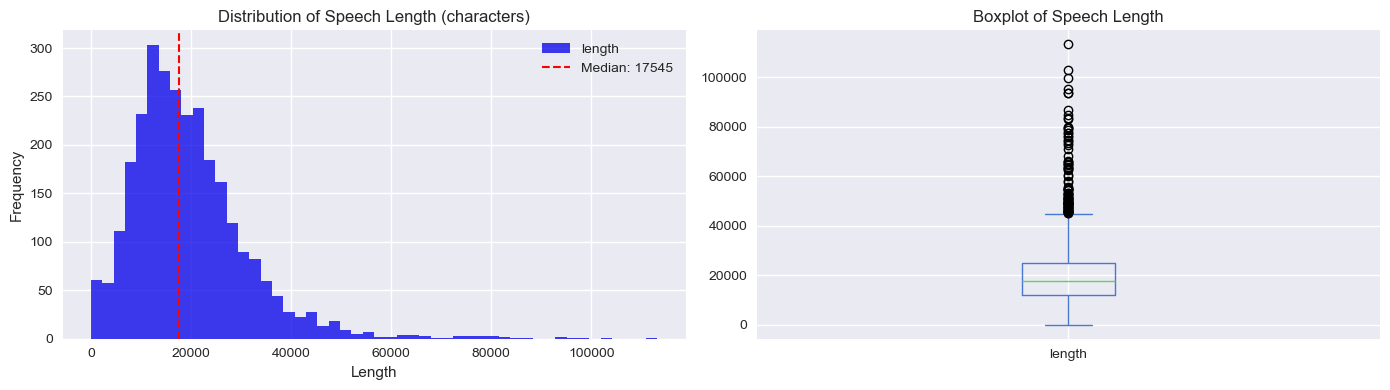

In [19]:
# Adding a length column (for the character count of contents)
raw["length"] = raw["contents"].str.len()

# Descriptive statistics
print(raw["length"].describe())

median_val = raw["length"].median()

# Creating distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

raw["length"].plot(kind="hist", bins=50, ax=axes[0], color="#0F0CEB", alpha=0.8)
axes[0].axvline(median_val, color="red", linestyle="--", linewidth=1.5, label=f"Median: {median_val:.0f}")
axes[0].legend()
axes[0].set_title("Distribution of Speech Length (characters)")
axes[0].set_xlabel("Length")

raw["length"].plot(kind="box", ax=axes[1])
axes[1].set_title("Boxplot of Speech Length")

plt.tight_layout()
plt.show()

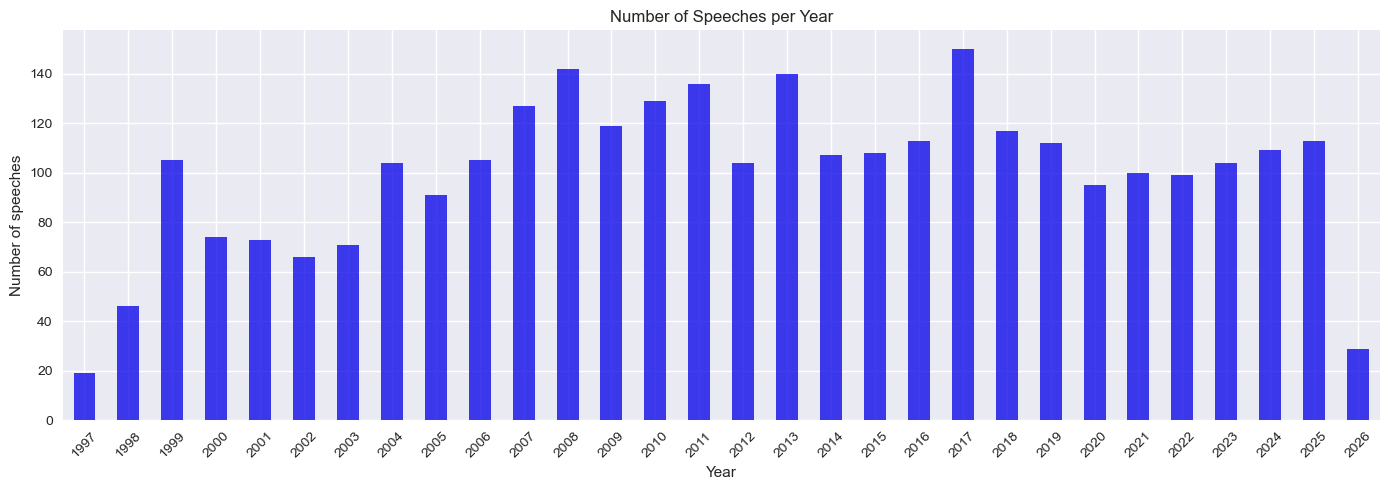

In [20]:
# Visualizing number of speeches per year
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw["year"] = raw["date"].dt.year

raw.groupby("year").size().plot(kind="bar", figsize=(14, 5), title="Number of Speeches per Year", color="#0F0CEB", alpha=0.8)
plt.xlabel("Year")
plt.ylabel("Number of speeches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cleaning, schema and unified text field

In this section, we:

- Strip whitespace and common encoding features.
- Remove footnote/boilerplate blocks from "contents" before building the text field.
- Build a unified "textraw" field as the concatenation of `title`, `subtitle`, and cleaned `contents`.
- Drop slide-only speeches: rows whose subtitle signals a slides/presentation format, or
  whose cleaned text is too short to be analytically meaningful (< 100 characters after stripping; modified this).
- Drop rows with completely empty text.

In [21]:
EXPECTED = ["date", "speakers", "title", "subtitle", "contents"]
missing = [c for c in EXPECTED if c not in raw.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = raw[EXPECTED].copy()
n_original = len(df) 

# Normalising the columns
for col in EXPECTED:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("\u00a0", " ", regex=False) # to make "Unicode U+00A0" spaces ordinary spaces
        .str.replace("\r", " ", regex=False) # to collapse multi-line text into a single line per cell
        .str.replace("\n", " ", regex=False)
        .str.strip() # to remove leading/trailing whitespace
    )

# dates 
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")


# Step A: Removing footnote / boilerplate blocks from contents 
# Footnotes in ECB speeches have:
#   - Numbered reference lines: "1.", "[1]", superscript-like numbers at line start
#   - Citation starters: lines beginning with "See ", "Cf.", "Source:", "Note:"
#   - Slide-caption boilerplate: "Chart", "Figure", "Table" followed by a number
# We split on double-whitespace (paragraph breaks), then drop paragraphs that look like footnote / caption blocks.

FOOTNOTE_PATTERNS = re.compile(
    r"^("
    r"\[?\d+\]?\.?\s"           # [1] or 1. at start
    r"|\d+\.\s"                 # 1. at start
    r"|See\s"                   # See ...
    r"|Cf\.\s"                  # Cf. ...
    r"|Source:"                 # Source:
    r"|Note:"                   # Note:
    r"|Chart\s\d"               # Chart 1
    r"|Figure\s\d"              # Figure 1
    r"|Table\s\d"               # Table 1
    r"|Graph\s\d"               # Graph 1
    r")",
    re.IGNORECASE
)

# This returns an empty string immediately if the input is NaN or entirely blank
def strip_footnotes(text: str) -> str:
    if pd.isna(text) or not str(text).strip():
        return ""
    # 1. Removing inline footnote markers:
    text = re.sub(r"(?<=\w)\d{1,2}(?=\s|,|\.|\))", "", text)
    # 2. Spliting into paragraphs and droping footnote-starting ones:
    paragraphs = re.split(r"\s{2,}", str(text))
    clean_paras = [p.strip() for p in paragraphs
                   if p.strip() and not FOOTNOTE_PATTERNS.match(p.strip())]
    return " ".join(clean_paras)

df["contents"] = df["contents"].apply(strip_footnotes)

# This is to prevent double counting of the content, if any:
df["contents"] = df["contents"].str.replace(
    r"^\s*SPEECH\s+", "", regex=True
).str.strip()


# Step B: Flagging and dropping slide-only speeches 
# Primary: Subtitle contains slide/presentation keywords
SLIDE_PATTERN = re.compile(
    r"\b(slides?|presentation|charts?|figures?|overhead)\b",
    re.IGNORECASE
)
df["is_slides"] = df["subtitle"].apply(
    lambda s: bool(SLIDE_PATTERN.search(str(s)))
)

n_slides = df["is_slides"].sum()
print(f"Slide-only speeches detected via subtitle: {n_slides}")
if n_slides:
    print(df.loc[df["is_slides"], ["date", "speakers", "subtitle"]].head(5).to_string())

df = df[~df["is_slides"]].drop(columns=["is_slides"]).reset_index(drop=True)


# Step C: Building the unified textraw 
def safe_str(x):
    return "" if pd.isna(x) else str(x)

# Replaced this istead of the block below to prevent double counting of the content if any
def build_textraw(row):
    title    = safe_str(row["title"]).strip()
    subtitle = safe_str(row["subtitle"]).strip()
    contents = safe_str(row["contents"]).strip()
    
    # Trying all possible duplicate prefixes, longest first
    for prefix in [title + " " + subtitle, subtitle, title]:
        if prefix and contents.startswith(prefix):
            contents = contents[len(prefix):].strip()
            break
    
    return f"{title} {subtitle} {contents}".strip()

df["textraw"] = df.apply(build_textraw, axis=1)

#df["textraw"] = (
#    df["title"].apply(safe_str) + " " +
#    df["subtitle"].apply(safe_str) + " " +
#    df["contents"].apply(safe_str)
#).str.strip().replace("", pd.NA)

n_before = len(df)
df = df.dropna(subset=["textraw"]).reset_index(drop=True)

# Secondary: drop rows whose textraw is still weirdly short (to catch slides that slipped past the subtitle filter)
MIN_CHARS = 100
short_mask = df["textraw"].str.len() < MIN_CHARS
n_short = short_mask.sum()
if n_short:
    print(f"\nAdditionally dropping {n_short} rows with textraw < {MIN_CHARS} chars (likely slides/empty):")
    print(df.loc[short_mask, ["date", "speakers", "subtitle"]].head(5).to_string())
df = df[~short_mask].reset_index(drop=True)

#print(f"\nRows retained after all cleaning: {len(df)}  (dropped {n_before - len(df)} from original)")
# Modified to show all drops from the original dataset, not only the last step:
print(f"Rows retained: {len(df)}  (dropped {n_original - len(df)} total from original {n_original})")
df[["date", "speakers", "title", "textraw"]].head(3)

Slide-only speeches detected via subtitle: 171
         date         speakers                                                                                                                                                                                         subtitle
0  2026-03-27  Isabel Schnabel                                 Slides by Isabel Schnabel, Member of the Executive Board of the European Central Bank, at Department of Economics at University of Zurich in Zurich, Switzerland
2  2026-03-25              nan                                                                      Slides by Philip R. Lane, Member of the Executive Board of the ECB, at The ECB and Its Watchers XXVI, in Frankfurt, Germany
7  2026-03-21  Piero Cipollone                                                              Slides by Piero Cipollone, Member of the Executive Board of the ECB, at BRIE-CITRIS, Bruegel and the Bank of Finland Joint Workshop
10 2026-03-06  Piero Cipollone                           

,date,speakers,title,textraw
0,2026-03-26,Luis de Guindos,Navigating turbulence: challenges for Europe a...,Navigating turbulence: challenges for Europe a...
1,2026-03-25,Christine Lagarde,Navigating energy shocks: risks and policy res...,Navigating energy shocks: risks and policy res...
2,2026-03-24,Piero Cipollone,The digital euro: preparing for a potential la...,The digital euro: preparing for a potential la...


In [22]:
print(df["speakers"].isna().sum())
print(df[df["speakers"] == "nan"][["date", "title"]].head())
# 2/3 have German titles

df["speakers"] = df["speakers"].replace("nan", pd.NA)
print(f"Rows with missing speakers: {df['speakers'].isna().sum()}")

# Dropping the rows with no speaker identified
n_before = len(df)
df = df.dropna(subset=["speakers"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows with missing speakers")
print(f"Remaining: {len(df)} speeches")

0
          date                                         title
262 2023-02-07  Monetary policy in times of pandemic and war
399 2021-06-22   Die Geldpolitik der EZB in der Corona-Krise
421 2021-03-18   Die Geldpolitik der EZB in der Corona-Krise
Rows with missing speakers: 3
Dropped 3 rows with missing speakers
Remaining: 2831 speeches


## Language detection and English-only filter

Each speech is assigned a `language` label using `langdetect`.

- Texts shorter than 50 characters are tagged as `'en'` by default rather than dropped.
- `assert` guarantees only English speeches remain after filtering.
- `language` column is retained for auditability.

In [23]:
MIN_LEN = 50   # chars below which we skip detection and default to 'en'

def detect_language(text):
    if pd.isna(text) or not str(text).strip():
        return "other"
    text = str(text).strip()
    if len(text) < MIN_LEN:
        return "en"   # keep short texts; flag rather than drop if any
    try:
        return "en" if detect(text) == "en" else "other"
    except LangDetectException:
        return "other"

df["language"] = df["textraw"].apply(detect_language)
print("Language distribution:")
print(df["language"].value_counts(dropna=False))

# Dropping non-English speeches and show which speakers are mainly affected
dropped = df[df["language"] != "en"]
if len(dropped):
    print("\nTop speakers in dropped (non-English) rows:")
    print(dropped["speakers"].value_counts().head(10))

df = df[df["language"] == "en"].reset_index(drop=True)

# Invariant check
assert set(df["language"]) == {"en"}, "Non-English rows still present!"
print(f"\nAfter filtering: {len(df)} English speeches retained.")

Language distribution:
language
en       2668
other     163
Name: count, dtype: int64

Top speakers in dropped (non-English) rows:
speakers
José Manuel González-Páramo    24
Jürgen Stark                   22
Gertrude Tumpel-Gugerell       22
Otmar Issing                   17
Eugenio Domingo Solans         17
Jörg Asmussen                  14
Jean-Claude Trichet            10
Yves Mersch                     9
Willem F. Duisenberg            8
Lorenzo Bini Smaghi             5
Name: count, dtype: int64

After filtering: 2668 English speeches retained.


In [24]:
# Checking how many were defaulted to 'en' due to their short length
short_en = df[df["textraw"].str.len() < 50]
print(f"Speeches kept by default (textraw < 50 chars): {len(short_en)}")
print(short_en[["date", "speakers", "textraw"]].head())

Speeches kept by default (textraw < 50 chars): 0
Empty DataFrame
Columns: [date, speakers, textraw]
Index: []


## Speaker normalisation and ECB role labels

- The DataFrame is exploded so each row represents one `(date, speaker, speech)`.
- Every retained speaker is assigned a `speaker_role` from a mapping.

**Role taxonomy:**
- `President` – ECB Presidents (Duisenberg, Trichet, Draghi, Lagarde)
- `Executive Board Member` – non-president Executive Board members
- `Other ECB Official` 

In [25]:
df["speakers_clean"] = (
    df["speakers"].astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

def split_speakers(s):
    if not s or pd.isna(s):
        return []
    return [p.strip() for p in re.split(r"[;,]", s) if p.strip()]

df["speaker_list"] = df["speakers_clean"].apply(split_speakers)

# Explode to one row per speaker
df_exp = df.explode("speaker_list").rename(columns={"speaker_list": "speaker"})
df_exp = df_exp.dropna(subset=["speaker"]).reset_index(drop=True)
print(f"Rows after explosion: {len(df_exp)}")

# ECB role mapping 
ROLE_MAP = {
    # Presidents
    "Christine Lagarde":           "President",
    "Mario Draghi":                "President",
    "Jean-Claude Trichet":         "President",
    "Willem F. Duisenberg":        "President",
    "Wim Duisenberg":              "President",
    # Executive Board Members
    "Piero Cipollone":             "Executive Board Member",
    "Isabel Schnabel":             "Executive Board Member",
    "Luis de Guindos":             "Executive Board Member",
    "Philip Lane":                 "Executive Board Member",
    # Due to variations in naming:
    "Philip R. Lane":              "Executive Board Member",
    "Fabio Panetta":               "Executive Board Member",
    "Frank Elderson":              "Executive Board Member",
    "Lorenzo Bini Smaghi":         "Executive Board Member",
    "Jose Manuel Gonzalez-Paramo": "Executive Board Member",
    "José Manuel González-Páramo": "Executive Board Member",
    "Gertrude Tumpel-Gugerell":    "Executive Board Member",
    "Eugenio Domingo Solans":      "Executive Board Member",
    "Otmar Issing":                "Executive Board Member",
    "Jürgen Stark":                "Executive Board Member",
    "Jurgen Stark":                "Executive Board Member",
    "Vítor Constâncio":            "Executive Board Member",
    "Vitor Constancio":            "Executive Board Member",
    "Benoît Coeuré":               "Executive Board Member",
    "Benoît Cœuré":                "Executive Board Member",
    "Peter Praet":                 "Executive Board Member",
    "Yves Mersch":                 "Executive Board Member",
    # I added these based on their past roles; but if you thought of this section differently 
    # like only the present board members, we can delete them:
    "Lucas Papademos":             "Executive Board Member",  # Vice-President 2002-2010
    "Sabine Lautenschläger":       "Executive Board Member",  # 2014-2019
    "Christian Noyer":             "Executive Board Member",  # Vice-President 1998-2002
    "Tommaso Padoa-Schioppa":      "Executive Board Member",  # founding member 1998-2005
    "Sirkka Hämäläinen":           "Executive Board Member",  # 1998-2003
    "Jörg Asmussen":               "Executive Board Member",  # 2012-2014
}

df_exp["speaker_role"] = df_exp["speaker"].map(ROLE_MAP).fillna("Other ECB Official")

# Keep a 'president' column (NaN for non-presidents)
PRESIDENTS = {k for k, v in ROLE_MAP.items() if v == "President"}
df_exp["president"] = df_exp["speaker"].where(df_exp["speaker"].isin(PRESIDENTS))

assert df_exp["speaker"].isna().sum() == 0,       "Missing speaker values!"
assert df_exp["speaker_role"].isna().sum() == 0,  "Missing speaker_role values!"

print("Speaker role counts:")
print(df_exp["speaker_role"].value_counts(dropna=False))
df_exp[["date", "speaker", "speaker_role", "title"]].head(5)

Rows after explosion: 2670
Speaker role counts:
speaker_role
Executive Board Member    1855
President                  808
Other ECB Official           7
Name: count, dtype: int64


,date,speaker,speaker_role,title
0,2026-03-26,Luis de Guindos,Executive Board Member,Navigating turbulence: challenges for Europe a...
1,2026-03-25,Christine Lagarde,President,Navigating energy shocks: risks and policy res...
2,2026-03-24,Piero Cipollone,Executive Board Member,The digital euro: preparing for a potential la...
3,2026-03-23,Philip R. Lane,Executive Board Member,AI and the euro area economy
4,2026-03-23,Piero Cipollone,Executive Board Member,Building the rails for Europe’s tokenised fina...


In [26]:
# Checking who is being classified as "Other ECB Official"
others = df_exp[df_exp["speaker_role"] == "Other ECB Official"]
print(others["speaker"].value_counts().to_string())

# The only one is Alexandre Lamfalussy (economist who served as President of the European Monetary Institute from 1994 to 1997, 
# which was the forerunner to the ECB.)

speaker
Alexandre Lamfalussy    7


# II. Text Pre-processing 
## Dual stopword strategies

`text_clean` is produced by collapsing whitespace without lowercasing. Capitalisation
is preserved so that spaCy can reliably detect proper nouns (`PROPN`), foreign words (`X`),
and other POS tags that depend on case.

Tokens are then lowercased after POS tagging.

**POS-based filtering:** Tokens tagged as `PROPN` (proper nouns like speaker names, city names),
`X` (foreign words: catches French/German fragments in bilingual passages), `SYM`, or `NUM`
are discarded before any stopword check.

Two token/lemma columns are created:

| Column | Purpose | Stopwords |
|---|---|---|
| `tokens_topic` / `lemmas_topic` | Topic modelling, word frequencies | spaCy defaults + ECB domain words + non-English function words |
| `tokens_sent` / `lemmas_sent` | Sentiment / stylistic analysis | spaCy defaults **minus** pronouns & negations |

The domain stopwords include months, titles/forms of address, citation abbreviations (pp, et, al, cf),
and common French/German/Italian/Spanish function words that survive language detection.

In [27]:
def clean_text(text):
    """Collapse whitespace only; do NOT lowercase yet.
    Lowercasing is deferred until after spaCy POS-tagging so that
    capitalisation cues (proper nouns, sentence starts) remain available
    for the tagger."""
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

df_exp["text_clean"] = df_exp["textraw"].apply(clean_text)

# Stopword sets 
# NOTE: all stopwords are stored in lowercase; comparison is always
#       against the lowercased token / lemma (done after POS tagging).
DOMAIN_SW = {
    # ECB boilerplate
    "european", "central", "bank", "ecb", "euro", "area",
    "speech", "remarks", "conference", "panel",
    "opening", "closing", "welcome", "thank", "thanks",
    "today", "tonight", "morning", "afternoon", "evening",
    # Months (if in datelines / headers)
    "january", "february", "march", "april", "may", "june",
    "july", "august", "september", "october", "november", "december",
    # Titles / forms of address
    "mr", "mrs", "ms", "dr", "prof", "professor",
    "president", "vice", "chairman", "chairwoman",
    "ladies", "gentlemen", "excellencies",
    "lecture", "organised", "keynote",
    # Common abbreviations & citation fragments that survive cleaning
    "pp", "et", "al", "eg", "ie", "cf", "op", "cit", "ibid",
    "vol", "no", "eds", "ed",
    # Non-English function words that slip through language detection
    # (French, German, Italian, Spanish fragments in bilingual passages)
    "de", "la", "le", "les", "des", "du", "un", "une", "en",
    "je", "il", "ce", "se", "ne", "pas", "que", "qui", "est",
    "et", "ou", "au", "aux", "sur", "dans", "par", "pour", "avec",
    "der", "die", "das", "und", "von", "den", "dem", "ein", "eine",
    "ist", "auf", "für", "mit", "nicht", "auch", "als", "wie",
    "di", "il", "del", "della", "che", "per", "con", "una",
    "el", "los", "las",
}

stopwords_topic = set(nlp.Defaults.stop_words) | DOMAIN_SW

KEEP_FOR_SENT = {"not", "no", "never", "n't", "none", "nobody",
                 "nowhere", "nothing", "neither", "nor",
                 "we", "i", "you", "they", "he", "she"}
stopwords_sent = set(nlp.Defaults.stop_words) - KEEP_FOR_SENT

# spaCy processing 
# Processing the ORIGINAL-CASE text so POS tagging is reliable, then lowercase the output tokens/lemmas afterward.
# Also filter:  PROPN (proper nouns), X (foreign/unknown), SYM (symbols),NUM-like tokens, single-character tokens.
DISCARD_POS = {"PROPN", "X", "SYM", "NUM", "PUNCT", "SPACE"}

toks_t, lems_t, toks_s, lems_s = [], [], [], []
n_tok_t, n_lem_t, n_tok_s, n_lem_s = [], [], [], []

texts = df_exp["text_clean"].tolist()
print(f"Processing {len(texts)} texts with spaCy (original case for POS)...")

for doc in nlp.pipe(texts, batch_size=64):
    tt, lt, ts, ls = [], [], [], []
    for t in doc:
        # Basic filters: punctuation, spaces, numbers, single chars
        if t.is_punct or t.is_space or t.like_num or len(t.text) <= 1:
            continue
        # Skip unwanted POS (proper nouns, foreign words, symbols)
        if t.pos_ in DISCARD_POS:
            continue
        # Lowercase for output & comparison
        word = t.text.lower()
        lemma = t.lemma_.lower()
        # Topic tokens: apply full stopword set
        if word not in stopwords_topic:
            tt.append(word)
        if lemma not in stopwords_topic:
            lt.append(lemma)
        # Sentiment tokens: keep pronouns & negations
        if word not in stopwords_sent:
            ts.append(word)
        if lemma not in stopwords_sent:
            ls.append(lemma)

    toks_t.append(tt); lems_t.append(lt)
    toks_s.append(ts); lems_s.append(ls)
    n_tok_t.append(len(tt)); n_lem_t.append(len(set(lt)))
    n_tok_s.append(len(ts)); n_lem_s.append(len(set(ls)))

df_exp["tokens_topic"]   = toks_t;  df_exp["lemmas_topic"]   = lems_t
df_exp["tokens_sent"]    = toks_s;  df_exp["lemmas_sent"]    = lems_s
df_exp["num_tok_topic"]  = n_tok_t; df_exp["num_lem_topic"]  = n_lem_t
df_exp["num_tok_sent"]   = n_tok_s; df_exp["num_lem_sent"]   = n_lem_s

# Checking if it worked 
sample = df_exp.iloc[0]
print("\n--- Stopword check (first speech, first 20 topic tokens) ---")
print(sample["tokens_topic"][:20])
print("\n--- First 20 sentiment tokens (note pronouns/negations kept) ---")
print(sample["tokens_sent"][:20])

# Quick check: any obvious junk still present?
all_topic_tokens = [tok for toks in df_exp["tokens_topic"] for tok in toks]
from collections import Counter
top100 = Counter(all_topic_tokens).most_common(100)
suspect = [w for w, c in top100 if len(w) <= 2 or w in ("mr", "sirkka", "inen", "pes", "je", "de", "la")]
if suspect:
    print(f"\n*** WARNING: suspect tokens in top-100: {suspect}")
else:
    print(f"\n*** OK: no obvious junk in top-100 topic tokens")

print("\nProcessing complete.")
df_exp[["speaker", "speaker_role", "num_tok_topic", "num_tok_sent"]].head(5)

Processing 2670 texts with spaCy (original case for POS)...

--- Stopword check (first speech, first 20 topic tokens) ---
['navigating', 'turbulence', 'challenges', 'path', 'ahead', 'introduction', 'privilege', 'deliver', 'memory', 'widely', 'regarded', 'intellectual', 'fathers', 'post', 'war', 'system', 'work', 'showed', 'external', 'shocks']

--- First 20 sentiment tokens (note pronouns/negations kept) ---
['navigating', 'turbulence', 'challenges', 'path', 'ahead', 'organised', 'introduction', 'privilege', 'deliver', 'lecture', 'memory', 'widely', 'regarded', 'intellectual', 'fathers', 'post', 'war', 'system', 'work', 'showed']

*** OK: no obvious junk in top-100 topic tokens

Processing complete.


,speaker,speaker_role,num_tok_topic,num_tok_sent
0,Luis de Guindos,Executive Board Member,951,1008
1,Christine Lagarde,President,1291,1412
2,Piero Cipollone,Executive Board Member,1427,1617
3,Philip R. Lane,Executive Board Member,5851,6161
4,Piero Cipollone,Executive Board Member,1048,1125


In [28]:
# This I am adding if we want to modify the stopwords or fix some earlier mistakes, so that we can test on the saved 
# dataset first then implement in the final run because each time it takes 40mins for me to run the cell above
import pickle
with open("df_exp_processed.pkl", "wb") as f:
    pickle.dump(df_exp, f)
print("Saved!")

## PROBLEM: It does not save due to large size; so if you want to check you need to delete the file before comitting any changes

# To use the saved data, uncomment
#import pickle
#with open("df_exp_processed.pkl", "rb") as f:
#    df_exp = pickle.load(f)
#print(f"Loaded: {len(df_exp)} rows")

Saved!


In [29]:
# Token number was too high for this, seems like the title and content is duplicated; adding another command above to fix this.
# I modified the codes above to account for possible duplication of title/subtitle in the content, 
# then I realized this particular speech is just long, nothing was a bug. But still kept the code modified
print(df_exp.loc[3, "textraw"][:500])
print(f"\nTotal chars: {len(df_exp.loc[3, 'textraw'])}")

AI and the euro area economy Keynote speech by Philip R. Lane, Member of the Executive Board of the ECB, at ECB-SAFE-RCEA International Conference on the Climate-Macro-Finance Interface (3CMFI) Frankfurt, 2 March 20 Introduction Artificial intelligence (AI) stands out as a potentially-transformative general-purpose technology (GPT).[1] The AI technological frontier has advanced at a remarkable pace, progressing from narrow machine-learning systems capable of pattern recognition to large language

Total chars: 87841


# III. Descriptive Analysis

Three outputs:
1. A summary table of the corpus.
2. Top-10 speakers by number of speeches, coloured by role.
3. Annual speech counts by speaker role.

In [44]:
from IPython.display import display
from collections import Counter

# Summary
words = df_exp["num_tok_topic"]
date_range = f"{df_exp['date'].min().date()}  →  {df_exp['date'].max().date()}"
summary = pd.DataFrame({
    "Metric": [
        "Total rows (1 row = 1 speaker × 1 speech)",
        "Unique speakers",
        "Unique roles",
        "Date range",
        "Min words / speech (topic tokens)",
        "Median words / speech (topic tokens)",
        "Max words / speech (topic tokens)",
        "Mean words / speech (topic tokens)",
    ],
    "Value": [
        len(df_exp),
        df_exp["speaker"].nunique(),
        df_exp["speaker_role"].nunique(),
        date_range,
        int(words.min()),
        int(words.median()),
        int(words.max()),
        round(words.mean(), 1),
    ]
})
print("=== Corpus summary ===")
display(summary.set_index("Metric"))

=== Corpus summary ===


,Value
Metric,
Total rows (1 row = 1 speaker × 1 speech),2670
Unique speakers,27
Unique roles,3
Date range,1997-02-07 → 2026-03-26
Min words / speech (topic tokens),1
Median words / speech (topic tokens),1185
Max words / speech (topic tokens),6911
Mean words / speech (topic tokens),1309.3


In [45]:
# Checked for duplicate (speaker, date, title) combinations as Cœuré & Draghi and Praet & Constâncio have the same number of speeches
dupes = df_exp[df_exp.duplicated(subset=["speaker", "date", "title"], keep=False)]
print(dupes[["speaker", "date", "title"]].sort_values(["speaker", "date"]).head(20))
print(f"There are {len(dupes)} duplicate rows for speaker, date or title.")

# Check the specific speakers in question
suspects = ["Benoît Cœuré", "Mario Draghi", "Peter Praet", "Vítor Constâncio"]
print("\nSpeech counts for suspects:")
print(df_exp[df_exp["speaker"].isin(suspects)].groupby("speaker").size().sort_values(ascending=False))

Empty DataFrame
Columns: [speaker, date, title]
Index: []
There are 0 duplicate rows for speaker, date or title.

Speech counts for suspects:
speaker
Benoît Cœuré        182
Mario Draghi        182
Peter Praet         122
Vítor Constâncio    122
dtype: int64


### Top-30 speakers by speech count 

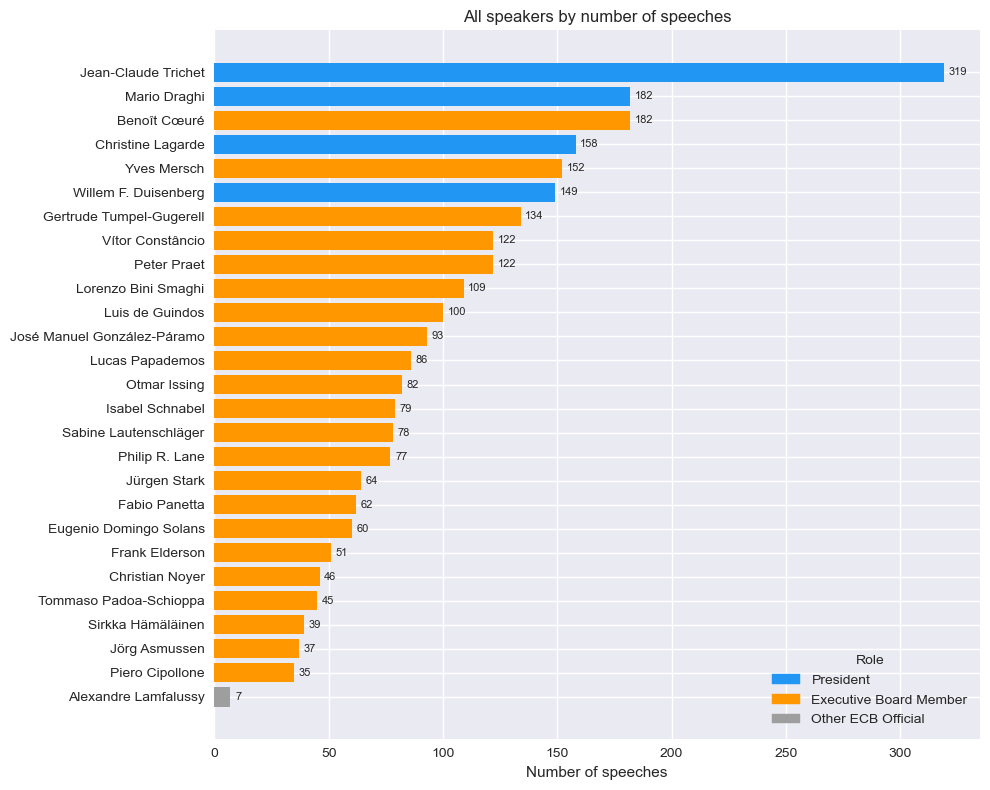

In [46]:
top30 = (
    df_exp.groupby(["speaker", "speaker_role"])
    .size().reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(30)
)
palette = {
    "President":              "#2196F3",
    "Executive Board Member": "#FF9800",
    "Other ECB Official":     "#9E9E9E",
}
colors = [palette.get(r, "#9E9E9E") for r in top30["speaker_role"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top30["speaker"][::-1], top30["n"][::-1], color=colors[::-1])
ax.set_xlabel("Number of speeches")
ax.set_title("All speakers by number of speeches")
handles = [plt.Rectangle((0,0),1,1, color=v) for v in palette.values()]
ax.legend(handles, palette.keys(), title="Role", loc="lower right")

# Add labels at the end of each bar to show the exact speech count.
for bar, val in zip(bars, top30["n"][::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", ha="left", fontsize=8)

plt.tight_layout()
plt.show()

### Annual speech volume by role 

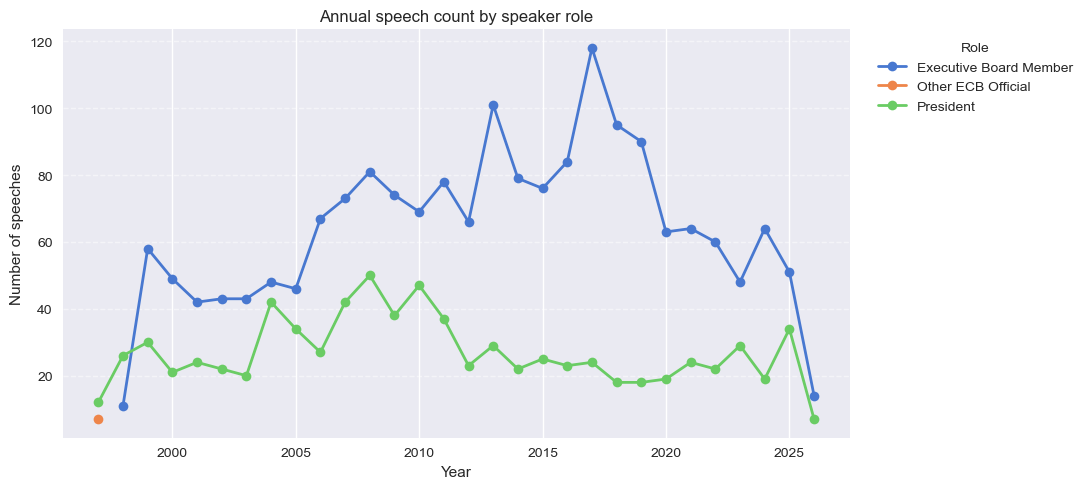

In [47]:
df_exp["year"] = df_exp["date"].dt.year
yr = df_exp.groupby(["year", "speaker_role"]).size().reset_index(name="n")

fig, ax = plt.subplots(figsize=(11, 5))
for role, grp in yr.groupby("speaker_role"):
    ax.plot(grp["year"], grp["n"], marker="o", label=role, linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Number of speeches")
ax.set_title("Annual speech count by speaker role")
ax.legend(title="Role", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Speech-length distribution by role (box plot) 

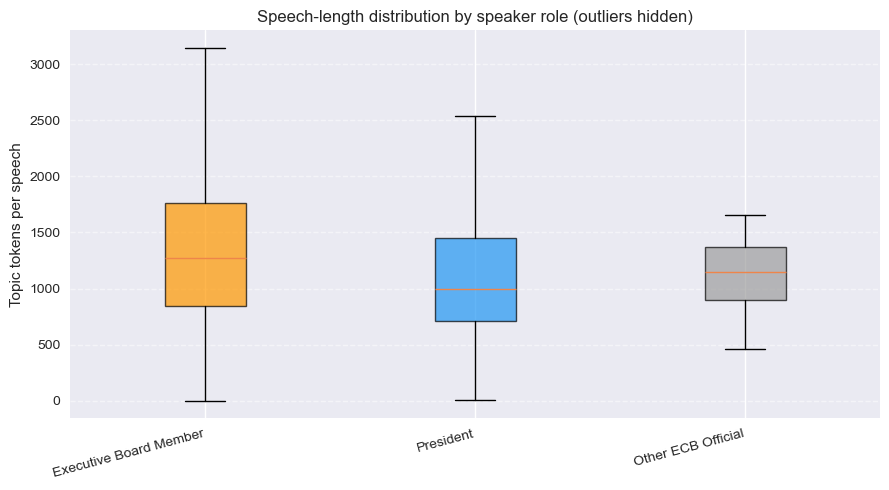

In [48]:
fig, ax = plt.subplots(figsize=(9, 5))
roles_ordered = df_exp["speaker_role"].value_counts().index.tolist()
data_by_role = [df_exp.loc[df_exp["speaker_role"] == r, "num_tok_topic"].values
                for r in roles_ordered]
bp = ax.boxplot(data_by_role, vert=True, patch_artist=True, showfliers=False)
role_colors = [palette.get(r, "#9E9E9E") for r in roles_ordered]
for patch, col in zip(bp["boxes"], role_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(roles_ordered)+1))
ax.set_xticklabels(roles_ordered, rotation=15, ha="right")
ax.set_ylabel("Topic tokens per speech")
ax.set_title("Speech-length distribution by speaker role (outliers hidden)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Median speech length per role (table) 

In [ ]:
print("\n=== Word-count statistics by speaker role ===")
length_stats = (
    df_exp.groupby("speaker_role")["num_tok_topic"]
    .agg(n_speeches="count", median="median", mean="mean", std="std",
         p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
    .round(1)
    .sort_values("median", ascending=False)
)
display(length_stats)


=== Word-count statistics by speaker role ===


,n_speeches,median,mean,std,p25,p75
speaker_role,,,,,,
Executive Board Member,1855,1271.0,1371.1,761.1,848.0,1766.5
Other ECB Official,7,1150.0,1114.3,414.2,899.0,1366.5
President,808,1000.0,1169.1,773.8,714.0,1452.0


### Top-20 content words per role

In [50]:
print("\n=== Top 20 content words per speaker role ===")
for role in df_exp["speaker_role"].unique():
    subset = df_exp.loc[df_exp["speaker_role"] == role, "tokens_topic"]
    all_toks = [tok for toks in subset for tok in toks]
    top20 = Counter(all_toks).most_common(20)
    words_str = ", ".join(f"{w} ({c})" for w, c in top20)
    print(f"\n[{role}]\n  {words_str}")



=== Top 20 content words per speaker role ===

[Executive Board Member]
  policy (32259), financial (31335), monetary (26284), banks (21213), market (18481), inflation (16924), economic (13755), stability (13060), price (11620), risk (11619), countries (11589), growth (11584), markets (11337), term (10690), rate (10491), rates (10390), crisis (9754), interest (8945), economy (8891), banking (8526)

[President]
  policy (11321), financial (10324), monetary (9725), inflation (7084), economic (6972), growth (6382), price (6022), stability (5992), market (5928), countries (5278), banks (4580), term (4579), markets (4372), economy (3959), rates (3795), time (3634), rate (3423), new (3384), global (3082), important (3041)

[Other ECB Official]
  monetary (138), policy (138), escb (92), market (65), financial (62), banks (55), inflation (51), stability (50), rates (49), rate (47), price (45), single (45), interest (43), national (41), exchange (40), countries (39), time (38), objective (32),

### Lexical richness (type–token ratio) by role


=== Lexical richness (unique lemmas / total lemmas) by role ===


,median,mean,std
speaker_role,,,
President,0.497,0.503,0.104
Other ECB Official,0.484,0.509,0.102
Executive Board Member,0.448,0.462,0.105


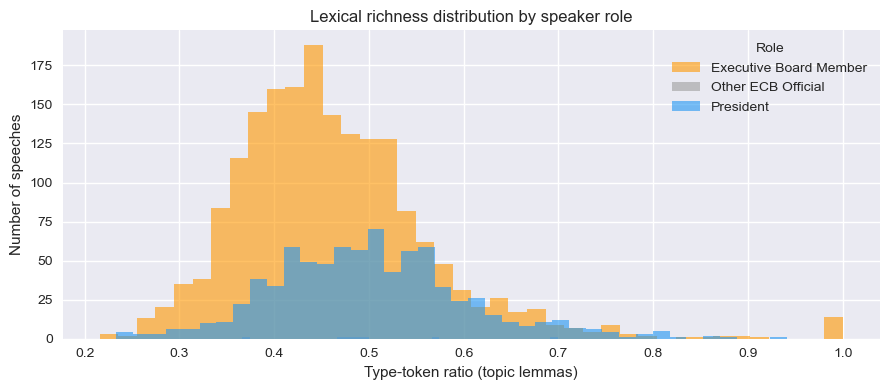

In [51]:
df_exp["ttr_topic"] = df_exp.apply(
    lambda row: (len(set(row["lemmas_topic"])) / len(row["lemmas_topic"])
                 if len(row["lemmas_topic"]) > 0 else np.nan),
    axis=1
)

print("\n=== Lexical richness (unique lemmas / total lemmas) by role ===")
ttr_stats = (
    df_exp.groupby("speaker_role")["ttr_topic"]
    .agg(median="median", mean="mean", std="std")
    .round(3)
    .sort_values("median", ascending=False)
)
display(ttr_stats)

fig, ax = plt.subplots(figsize=(9, 4))
for role, grp in df_exp.groupby("speaker_role"):
    vals = grp["ttr_topic"].dropna()
    ax.hist(vals, bins=40, alpha=0.6, label=role,
            color=palette.get(role, "#9E9E9E"))
ax.set_xlabel("Type-token ratio (topic lemmas)")
ax.set_ylabel("Number of speeches")
ax.set_title("Lexical richness distribution by speaker role")
ax.legend(title="Role")
plt.tight_layout()
plt.show()


### TF-IDF: distinctive words per speaker role

Instead of raw frequency counts (which surface generic ECB boilerplate for every role), TF-IDF
identifies words that are **relatively distinctive** for each role compared to the others.

- Each role's corpus is treated as a single "document" (all speeches concatenated).
- `TfidfVectorizer` computes TF-IDF scores across the three role-documents.
- Words with the highest score for a given role are the ones that appear frequently within
  that role but are relatively rare across the other roles.

* Data-driven exercice so no need for a manual word removal here.

=== Top 20 TF-IDF distinctive words per speaker role ===

[Executive Board Member]
  digital (0.0169), supervisory (0.0167), policy (0.0165), financial (0.0165), funding (0.0164), models (0.0163), monetary (0.0162), loans (0.0161), purchases (0.0161), outlook (0.016), model (0.016), energy (0.016), banks (0.0159), pandemic (0.0159), sectors (0.0158), question (0.0158), programme (0.0158), instance (0.0157), market (0.0157), systemic (0.0156)

[Other ECB Official]
  policy (0.0649), monetary (0.0649), escb (0.0605), market (0.0567), financial (0.0562), banks (0.0549), inflation (0.054), stability (0.0538), rates (0.0536), rate (0.0531), price (0.0527), single (0.0527), interest (0.0522), national (0.0516), exchange (0.0514), countries (0.0511), time (0.0508), objective (0.0489), strategy (0.0482), economic (0.0482)

[President]
  policy (0.0196), outlook (0.0194), financial (0.0194), monetary (0.0193), question (0.0191), energy (0.0189), think (0.0189), inflation (0.0187), economic (0.0

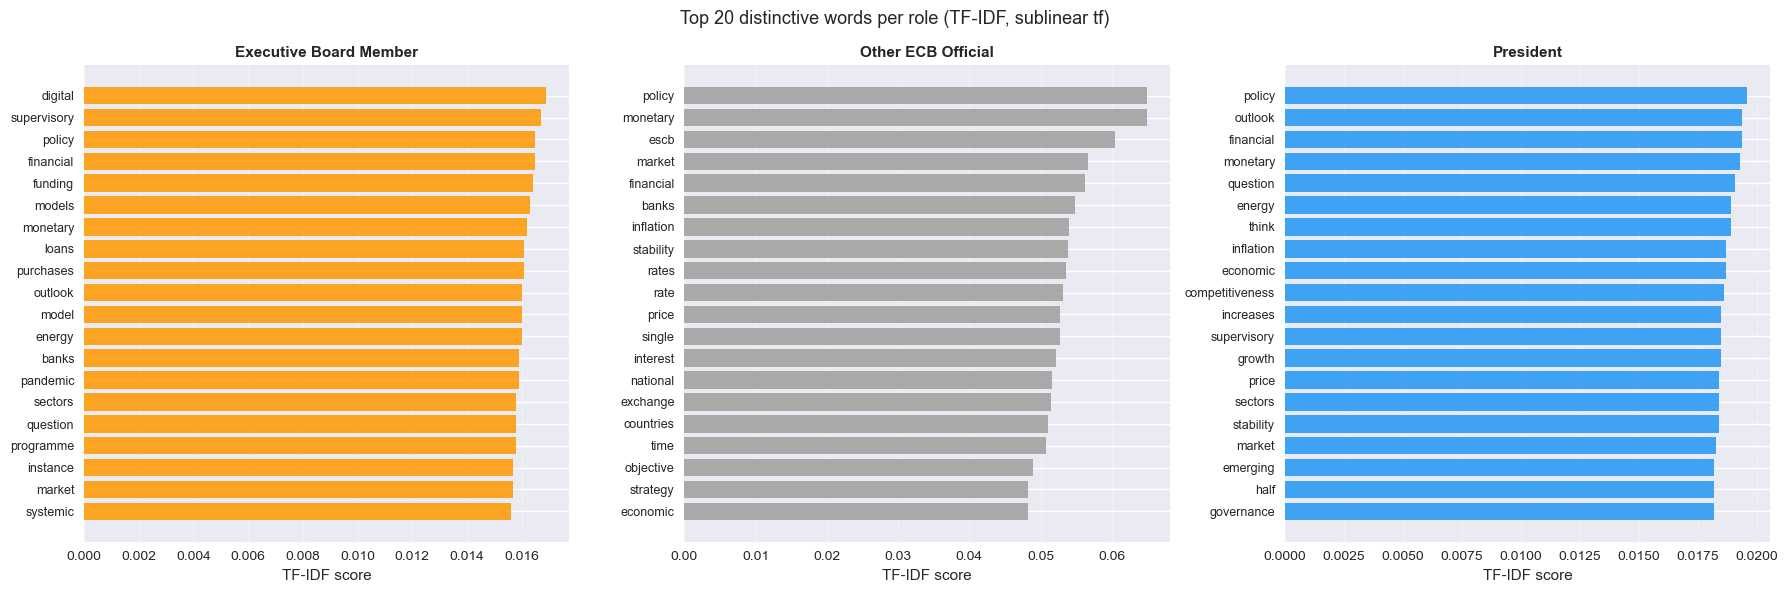

Saved to ecb_speeches_clean_en_exploded.csv  (2670 rows)


In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Building one document per role (joining all topic tokens) 
role_docs = (
    df_exp.groupby("speaker_role")["tokens_topic"]
    .apply(lambda col: " ".join(" ".join(toks) for toks in col))
    .reset_index()
    .rename(columns={"tokens_topic": "role_text"})
)

roles   = role_docs["speaker_role"].tolist()
corpora = role_docs["role_text"].tolist()

# Fitting TF-IDF (already tokenised, so no further tokenisation needed)
vec = TfidfVectorizer(
    analyzer="word",
    token_pattern=r"[a-zA-Z'\-]{2,}",   # words of at least 2 chars
    max_features=20_000,
    sublinear_tf=True,                    # log(1+tf) dampens very common words
)
tfidf_matrix = vec.fit_transform(corpora)   # shape: (n_roles, n_vocab)
vocab = vec.get_feature_names_out()

# Top-N distinctive words per role
TOP_N = 20
print(f"=== Top {TOP_N} TF-IDF distinctive words per speaker role ===\n")

role_top_words = {}
for i, role in enumerate(roles):
    scores   = tfidf_matrix[i].toarray().flatten()
    top_idx  = scores.argsort()[::-1][:TOP_N]
    top_words = [(vocab[j], round(scores[j], 4)) for j in top_idx]
    role_top_words[role] = top_words
    words_str = ", ".join(f"{w} ({s})" for w, s in top_words)
    print(f"[{role}]\n  {words_str}\n")

# Visuals
palette = {
    "President":              "#2196F3",
    "Executive Board Member": "#FF9800",
    "Other ECB Official":     "#9E9E9E",
}

fig, axes = plt.subplots(1, len(roles), figsize=(6 * len(roles), 6), sharey=False)

for ax, role in zip(axes, roles):
    words_scores = role_top_words[role]
    ws = [w for w, _ in words_scores]
    ss = [s for _, s in words_scores]
    ax.barh(ws[::-1], ss[::-1], color=palette.get(role, "#9E9E9E"), alpha=0.85)
    ax.set_title(role, fontsize=11, fontweight="bold")
    ax.set_xlabel("TF-IDF score")
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle(f"Top {TOP_N} distinctive words per role (TF-IDF, sublinear tf)", fontsize=13)
plt.tight_layout()
plt.show()

OUTPUT_PATH = "ecb_speeches_clean_en_exploded.csv"

cols_to_save = [
    "date", "speaker", "speaker_role", "president", "language",
    "title", "subtitle", "contents", "textraw", "text_clean",
    "num_tok_topic", "num_lem_topic", "num_tok_sent", "num_lem_sent"
]
df_exp[cols_to_save].to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}  ({len(df_exp)} rows)")

## Frequency Distributions — Top 50 Unigrams & Bigrams

Here, we compute the most frequent unigrams and bigrams across the full corpus using topic tokens (domain stopwords are already removed). 

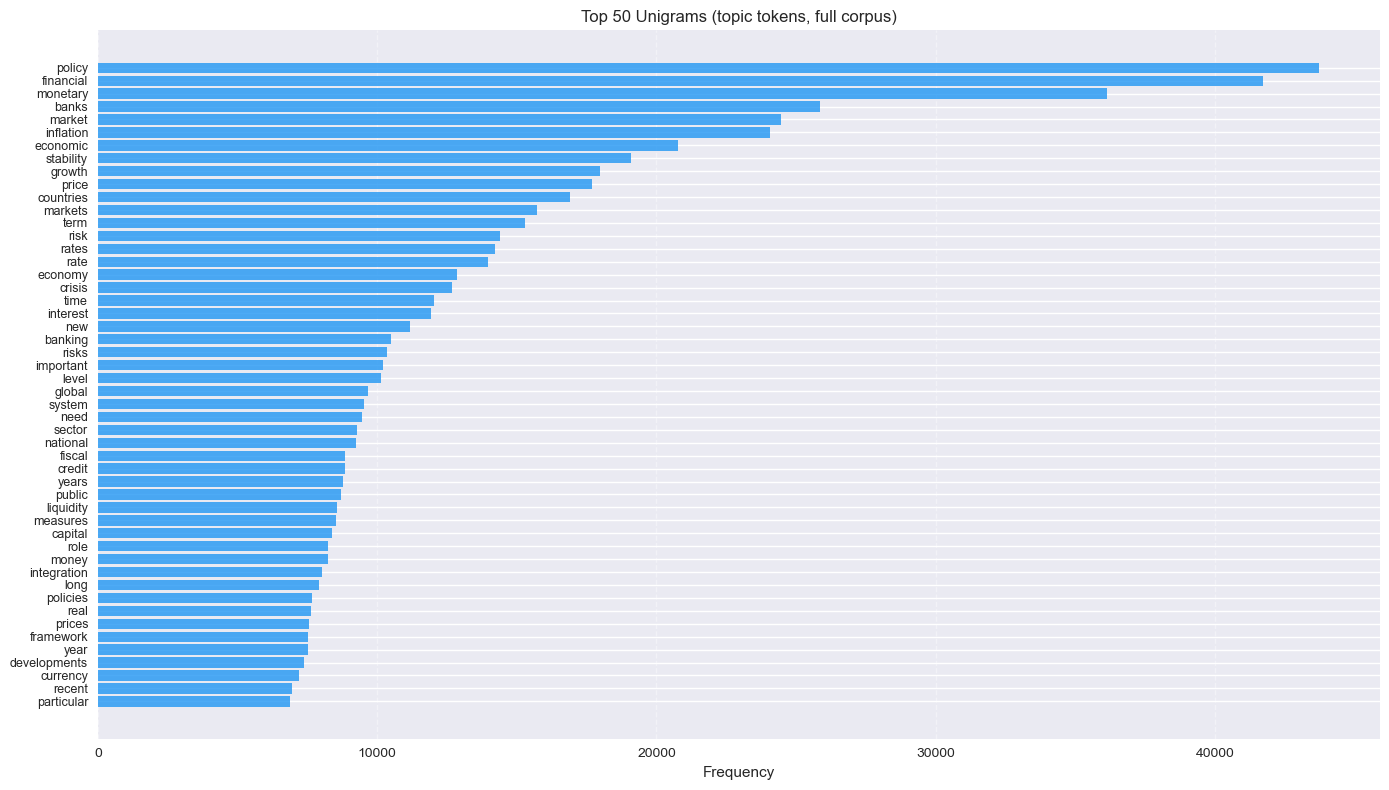

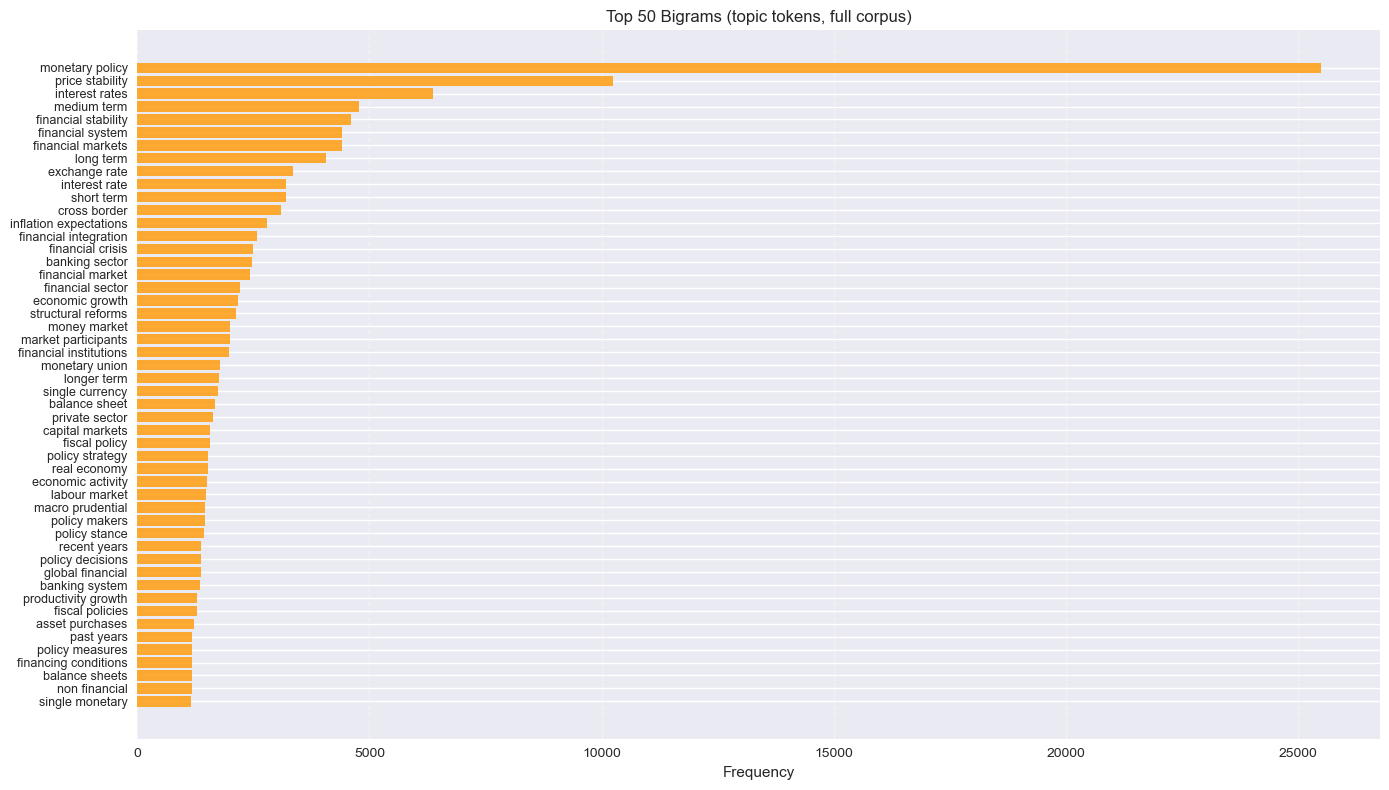

Vocabulary size: 32,705 unique tokens (digits excluded)
Total tokens: 3,495,735
Unique bigrams: 1,355,392


In [ ]:
from collections import Counter
from itertools import islice

# Top 50 unigrams
# Filtering out pure-digit tokens (year fragments, footnote numbers, etc.)
all_tokens = [tok for toks in df_exp["tokens_topic"] for tok in toks if not tok.isdigit()]
uni_counts = Counter(all_tokens)
top50_uni = uni_counts.most_common(50)

fig, ax = plt.subplots(figsize=(14, 8))
words, counts = zip(*top50_uni)
ax.barh(range(len(words)), counts[::-1], color="#2196F3", alpha=0.8)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words[::-1], fontsize=9)
ax.set_xlabel("Frequency")
ax.set_title("Top 50 Unigrams (topic tokens, full corpus)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Top 50 bigrams 
def get_bigrams(token_list):
    # Skip bigrams containing pure digits
    return [(a, b) for a, b in zip(token_list[:-1], token_list[1:])
            if not a.isdigit() and not b.isdigit()]

all_bigrams = [bg for toks in df_exp["tokens_topic"] for bg in get_bigrams(toks)]
bi_counts = Counter(all_bigrams)
top50_bi = bi_counts.most_common(50)

fig, ax = plt.subplots(figsize=(14, 8))
labels = [f"{w1} {w2}" for (w1, w2), _ in top50_bi]
counts_bi = [c for _, c in top50_bi]
ax.barh(range(len(labels)), counts_bi[::-1], color="#FF9800", alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel("Frequency")
ax.set_title("Top 50 Bigrams (topic tokens, full corpus)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Vocabulary size: {len(uni_counts):,} unique tokens (digits excluded)")
print(f"Total tokens: {len(all_tokens):,}")
print(f"Unique bigrams: {len(bi_counts):,}")

## Word Clouds
Here, we produce:
- Full corpus word cloud
- Word clouds split by speaker role (President, Executive Board Member, Other ECB Official)

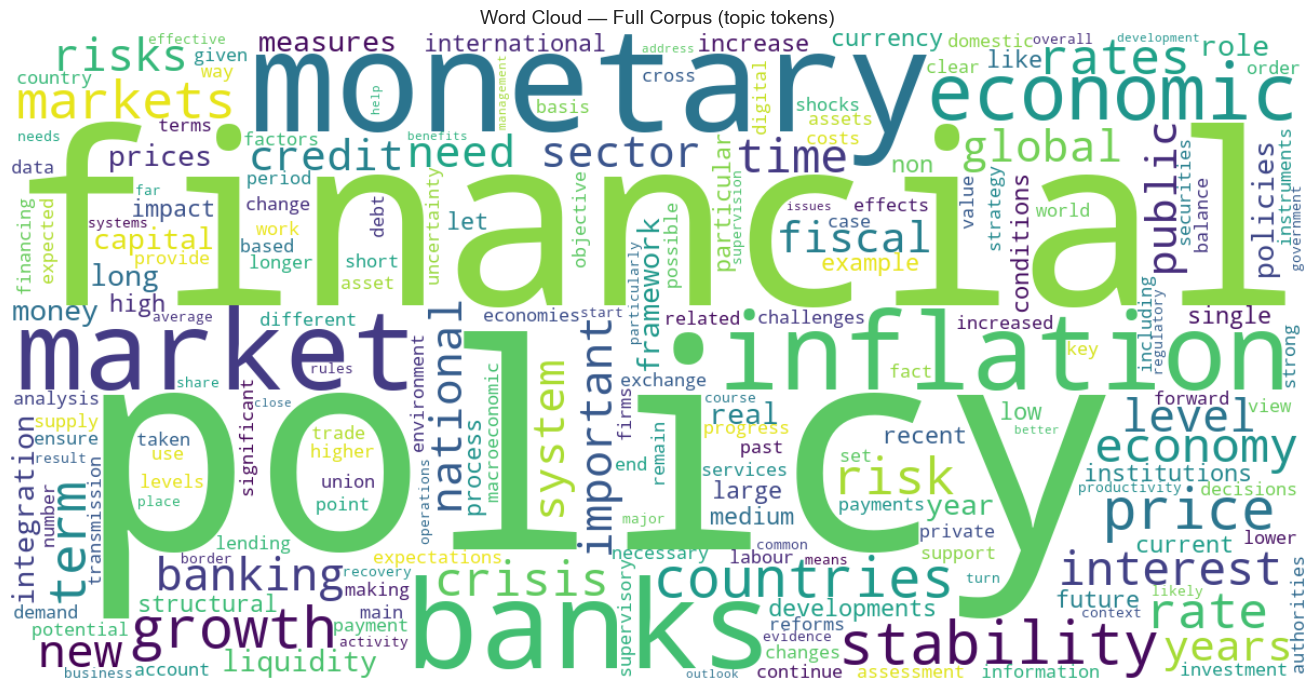

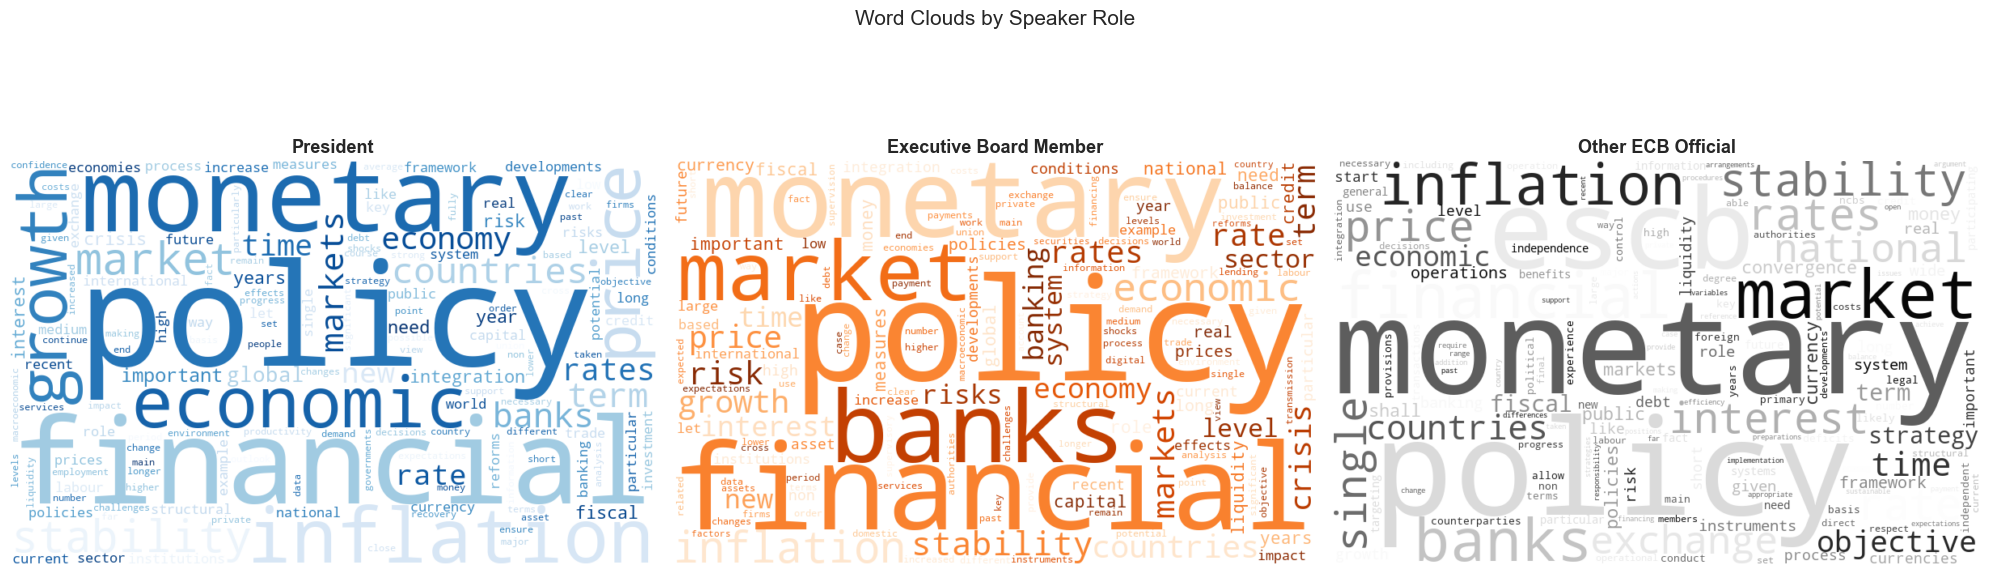

In [54]:
from wordcloud import WordCloud

# Full corpus word cloud 
wc_full = WordCloud(width=1200, height=600, max_words=200,
                    background_color="white", colormap="viridis",
                    collocations=False)
wc_full.generate_from_frequencies(uni_counts)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc_full, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — Full Corpus (topic tokens)", fontsize=14)
plt.tight_layout()
plt.show()

# Word clouds by speaker role
roles = ["President", "Executive Board Member", "Other ECB Official"]
role_colors = {"President": "Blues", "Executive Board Member": "Oranges",
               "Other ECB Official": "Greys"}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, role in zip(axes, roles):
    subset = df_exp[df_exp["speaker_role"] == role]
    role_tokens = [tok for toks in subset["tokens_topic"] for tok in toks]
    role_freq = Counter(role_tokens)
    wc = WordCloud(width=800, height=500, max_words=150,
                   background_color="white", colormap=role_colors[role],
                   collocations=False)
    wc.generate_from_frequencies(role_freq)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(role, fontsize=13, fontweight="bold")

fig.suptitle("Word Clouds by Speaker Role", fontsize=15)
plt.tight_layout()
plt.show()

## Corpus Statistics Summary

Overview of the corpus: speech counts, token distributions, temporal coverage.

,Value
Total speeches (rows),2670
Unique speakers,27
Unique speech dates,2094
Date range,1997-02-07 to 2026-03-26
Years covered,30
Avg tokens/speech (topic),1309
Median tokens/speech (topic),1185
Total tokens (topic),"3,495,735"
Vocabulary size (unique),"32,705"


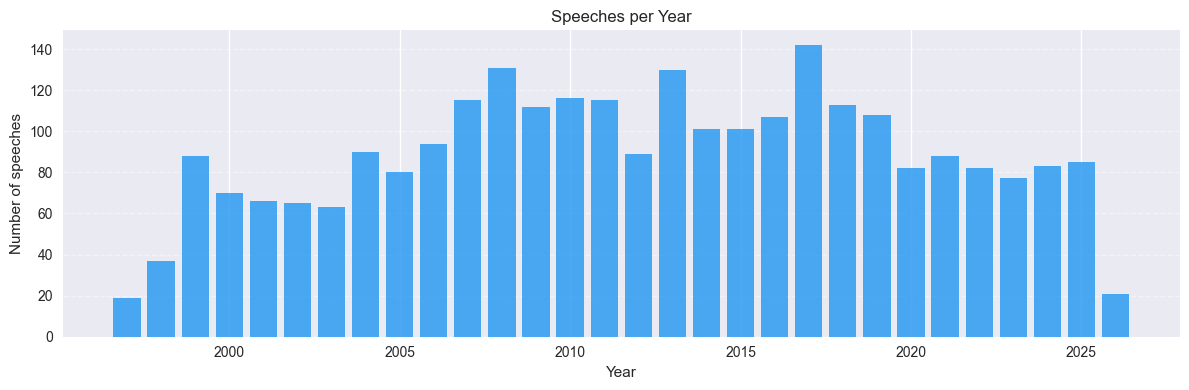

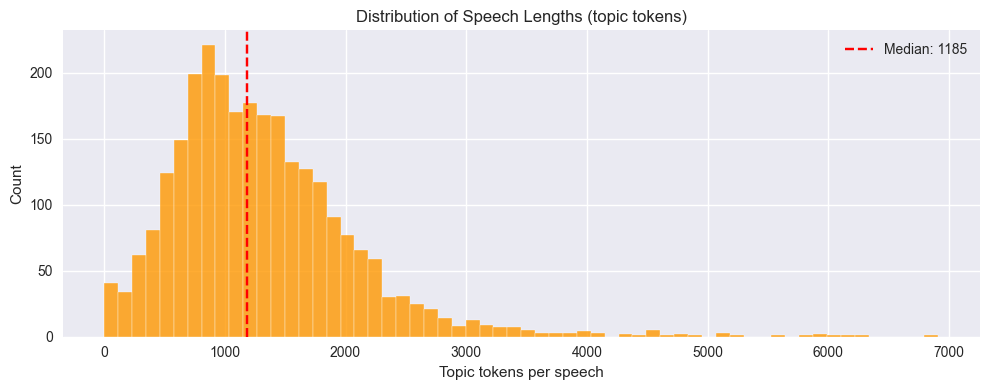

In [ ]:
from IPython.display import display

# Basic statistics
df_exp["year"] = df_exp["date"].dt.year

stats = {
    "Total speeches (rows)": len(df_exp),
    "Unique speakers": df_exp["speaker"].nunique(),
    "Unique speech dates": df_exp["date"].nunique(),
    "Date range": f"{df_exp['date'].min().date()} to {df_exp['date'].max().date()}",
    "Years covered": int(df_exp["year"].max() - df_exp["year"].min() + 1),
    "Avg tokens/speech (topic)": f"{df_exp['num_tok_topic'].mean():.0f}",
    "Median tokens/speech (topic)": f"{df_exp['num_tok_topic'].median():.0f}",
    "Total tokens (topic)": f"{df_exp['num_tok_topic'].sum():,}",
    "Vocabulary size (unique)": f"{len(uni_counts):,}",
}
display(pd.DataFrame.from_dict(stats, orient="index", columns=["Value"]))

# Speeches over time 
yearly = df_exp.groupby("year").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yearly.index, yearly.values, color="#2196F3", alpha=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Number of speeches")
ax.set_title("Speeches per Year")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Token length distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_exp["num_tok_topic"], bins=60, color="#FF9800", alpha=0.8, edgecolor="white")
ax.axvline(df_exp["num_tok_topic"].median(), color="red", linestyle="--", label=f"Median: {df_exp['num_tok_topic'].median():.0f}")
ax.set_xlabel("Topic tokens per speech")
ax.set_ylabel("Count")
ax.set_title("Distribution of Speech Lengths (topic tokens)")
ax.legend()
plt.tight_layout()
plt.show()

# IV. Topic Modelling — LDA with Coherence Search

- Build a gensim dictionary and bag-of-words corpus from topic lemmas
- Search over k = 5..20 topics using c_v coherence
- Plot the coherence curve and select the optimal k
- Display top 10 words per topic with human-readable labels

### Dictionary Building and Coherence Search

In [55]:
from gensim import corpora, models
from gensim.models import CoherenceModel

# Building dictionary and corpus 
texts_for_lda = df_exp["lemmas_topic"].tolist()

dictionary = corpora.Dictionary(texts_for_lda)
# Filtering extremes: remove tokens in <5 docs or >60% of docs
dictionary.filter_extremes(no_below=5, no_above=0.6)
corpus_bow = [dictionary.doc2bow(doc) for doc in texts_for_lda]

print(f"Dictionary size: {len(dictionary)} terms")
print(f"Corpus size: {len(corpus_bow)} documents")

# Coherence search over k = 5..20
K_RANGE = range(5, 21)
coherence_scores = []

print("Running LDA coherence search...")
for k in K_RANGE:
    lda = models.LdaModel(
        corpus_bow, num_topics=k, id2word=dictionary,
        passes=10, iterations=100, random_state=42
    )
    cm = CoherenceModel(model=lda, texts=texts_for_lda, dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  k={k:2d}  coherence={score:.4f}")

print("\nCoherence search complete.")

Dictionary size: 8588 terms
Corpus size: 2670 documents
Running LDA coherence search...
  k= 5  coherence=0.4717
  k= 6  coherence=0.4933
  k= 7  coherence=0.5053
  k= 8  coherence=0.4998
  k= 9  coherence=0.5186
  k=10  coherence=0.5347
  k=11  coherence=0.5325
  k=12  coherence=0.5311
  k=13  coherence=0.5280
  k=14  coherence=0.5233
  k=15  coherence=0.5176
  k=16  coherence=0.5295
  k=17  coherence=0.5498
  k=18  coherence=0.5256
  k=19  coherence=0.5227
  k=20  coherence=0.5370

Coherence search complete.


### Coherence curve 

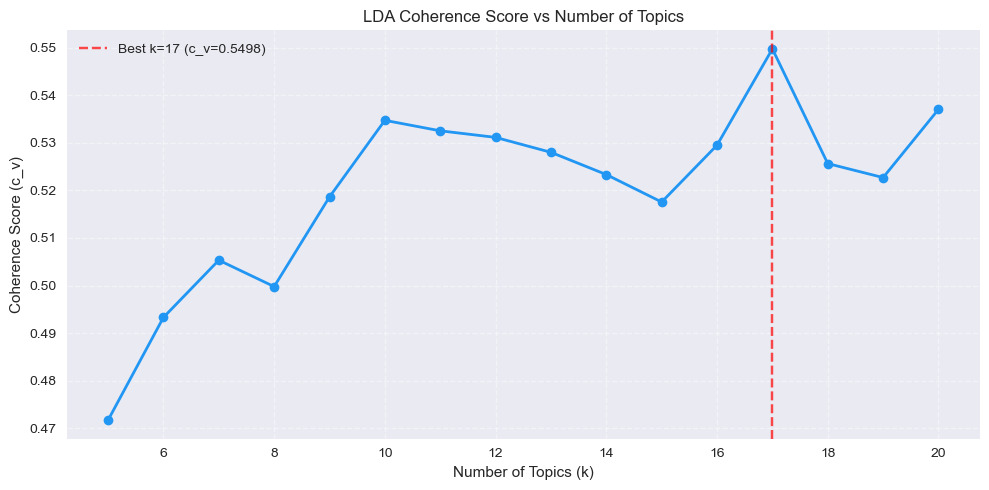


Optimal k = 17 with coherence = 0.5498


In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_RANGE), coherence_scores, marker="o", linewidth=2, color="#2196F3")
best_idx = coherence_scores.index(max(coherence_scores))
best_k = list(K_RANGE)[best_idx]
ax.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"Best k={best_k} (c_v={max(coherence_scores):.4f})")
ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Coherence Score (c_v)")
ax.set_title("LDA Coherence Score vs Number of Topics")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nOptimal k = {best_k} with coherence = {max(coherence_scores):.4f}")

In [58]:
# Training final LDA model with optimal or chosen k 
chosen_k = 10  # We select this over best_k=17 for interpretability, and given the sample size of our dataset
lda_best = models.LdaModel(
    corpus_bow, num_topics=chosen_k, id2word=dictionary,
    passes=20, iterations=200, random_state=42
)

# Display top 10 words per topic
print(f"=== LDA Model: {chosen_k} topics ===\n")
for topic_id in range(chosen_k):
    top_words = lda_best.show_topic(topic_id, topn=10)
    words_str = ", ".join(f"{w} ({p:.3f})" for w, p in top_words)
    print(f"Topic {topic_id:2d}: {words_str}")

=== LDA Model: 10 topics ===

Topic  0: payment (0.049), banknote (0.018), money (0.015), digital (0.014), service (0.013), cash (0.013), card (0.009), coin (0.008), retail (0.007), scheme (0.007)
Topic  1: shock (0.009), purchase (0.009), expectation (0.008), demand (0.007), firm (0.007), rise (0.006), household (0.006), supply (0.006), energy (0.005), bond (0.005)
Topic  2: question (0.009), think (0.008), currency (0.007), political (0.006), single (0.005), know (0.005), people (0.005), independence (0.004), member (0.004), course (0.004)
Topic  3: integration (0.031), border (0.012), cross (0.012), security (0.011), single (0.011), service (0.007), bond (0.007), settlement (0.006), infrastructure (0.006), competition (0.006)
Topic  4: liquidity (0.017), fund (0.007), prudential (0.006), supervision (0.006), supervisory (0.006), management (0.006), money (0.005), operation (0.005), macro (0.005), collateral (0.005)
Topic  5: strategy (0.022), analysis (0.015), money (0.013), informa

### Topic Labels

After inspecting the top words, assign a short human-readable label to each topic. Edit the `TOPIC_LABELS` dictionary below after reviewing the output above.

Topic labels:
  Topic  0: Digital Payments & Retail CBDC
  Topic  1: Macroeconomic Shocks & Demand
  Topic  2: Political Discourse & Currency Sovereignty
  Topic  3: Financial Market Integration
  Topic  4: Liquidity & Prudential Supervision
  Topic  5: Statistical Analysis & Uncertainty
  Topic  6: Economic Outlook & Fiscal Monitoring
  Topic  7: Exchange Rates & International Integration
  Topic  8: Labour Market & Structural Reform
  Topic  9: Fiscal Policy, Debt & Governance

Topic distribution across speeches:
topic_label
Macroeconomic Shocks & Demand                 562
Liquidity & Prudential Supervision            480
Political Discourse & Currency Sovereignty    283
Fiscal Policy, Debt & Governance              268
Exchange Rates & International Integration    217
Digital Payments & Retail CBDC                212
Financial Market Integration                  210
Labour Market & Structural Reform             149
Statistical Analysis & Uncertainty            145
Economic Outlook 

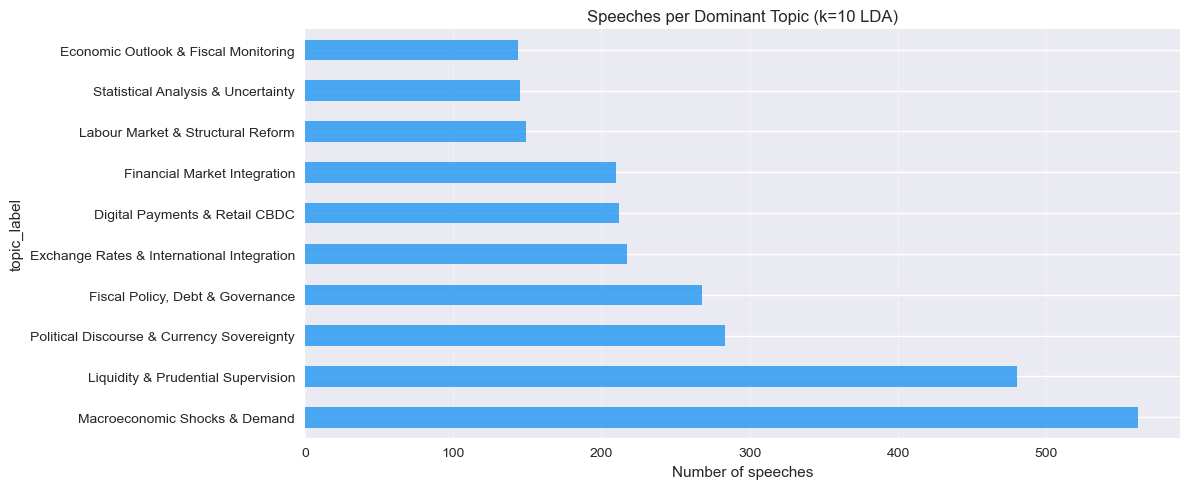

In [59]:
# ── Auto-generation of topic labels from top words ──────────────────────────
# I replaced this block with the manual one, but keeping it here in case we want to revert to it or use it as a starting point for the manual labels.
#TOPIC_LABELS = {}
#for topic_id in range(chosen_k):
#    top3 = [w for w, _ in lda_best.show_topic(topic_id, topn=3)]
#    TOPIC_LABELS[topic_id] = " / ".join(top3)

#print("Provisional topic labels:")
#for tid, label in TOPIC_LABELS.items():
#    print(f"  Topic {tid:2d}: {label}")

# Defining topic labels manually
TOPIC_LABELS = {
    0: "Digital Payments & Retail CBDC",
    1: "Macroeconomic Shocks & Demand",
    2: "Political Discourse & Currency Sovereignty",
    3: "Financial Market Integration",
    4: "Liquidity & Prudential Supervision",
    5: "Statistical Analysis & Uncertainty",
    6: "Economic Outlook & Fiscal Monitoring",
    7: "Exchange Rates & International Integration",
    8: "Labour Market & Structural Reform",
    9: "Fiscal Policy, Debt & Governance",
}

print("Topic labels:")
for tid, label in TOPIC_LABELS.items():
    print(f"  Topic {tid:2d}: {label}")

# Assigning dominant topic to each speech
def get_dominant_topic(bow):
    topic_probs = lda_best.get_document_topics(bow, minimum_probability=0.0)
    return max(topic_probs, key=lambda x: x[1])

dominant = [get_dominant_topic(bow) for bow in corpus_bow]
df_exp["dominant_topic"] = [t for t, _ in dominant]
df_exp["topic_prob"] = [p for _, p in dominant]
df_exp["topic_label"] = df_exp["dominant_topic"].map(TOPIC_LABELS)

print(f"\nTopic distribution across speeches:")
print(df_exp["topic_label"].value_counts())

# Topic distribution bar chart
topic_dist = df_exp["topic_label"].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
topic_dist.plot(kind="barh", ax=ax, color="#2196F3", alpha=0.8)
ax.set_xlabel("Number of speeches")
ax.set_title("Speeches per Dominant Topic (k=10 LDA)")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# pyLDAvis interactive visualisation 
import pyLDAvis
import pyLDAvis.gensim_models

vis_data = pyLDAvis.gensim_models.prepare(lda_best, corpus_bow, dictionary, sort_topics=False)
pyLDAvis.display(vis_data)

## Classification — SVC & XGBoost on Dominant Topic

- Target: dominant LDA topic (from Step 12)
- Features: TF-IDF on topic tokens
- Models: LinearSVC and XGBoost with GridSearchCV
- Metrics: accuracy, macro F1, confusion matrix

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import xgboost as xgb
# the goal is to build a fast, deployable classifier for labelling new unseen speeches without running LDA again; 
# not to "validate" the LDA model, since the labels themselves come from it

# Preparing features and target 
# Joining topic tokens back into strings for TF-IDF
df_exp["tokens_topic_str"] = df_exp["tokens_topic"].apply(lambda toks: " ".join(toks))
X = df_exp["tokens_topic_str"]
y = df_exp["dominant_topic"]

print(f"Classes: {sorted(y.unique())}")
print(f"Class distribution:\n{y.value_counts().sort_index()}")

# Train/test split (stratified)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Class distribution:
dominant_topic
0    212
1    562
2    283
3    210
4    480
5    145
6    144
7    217
8    149
9    268
Name: count, dtype: int64

Train: 2136, Test: 534


Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best SVC params: {'svc__C': 1.0, 'tfidf__max_features': 15000}
Best CV F1 (macro): 0.8721

LinearSVC — Test Set
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.93      0.96      0.94       112
           2       0.90      0.81      0.85        57
           3       0.97      0.79      0.87        42
           4       0.89      0.97      0.93        96
           5       0.85      0.79      0.82        29
           6       0.80      0.83      0.81        29
           7       0.87      0.93      0.90        43
           8       0.85      0.77      0.81        30
           9       0.84      0.87      0.85        54

    accuracy                           0.89       534
   macro avg       0.89      0.87      0.87       534
weighted avg       0.89      0.89      0.89       534



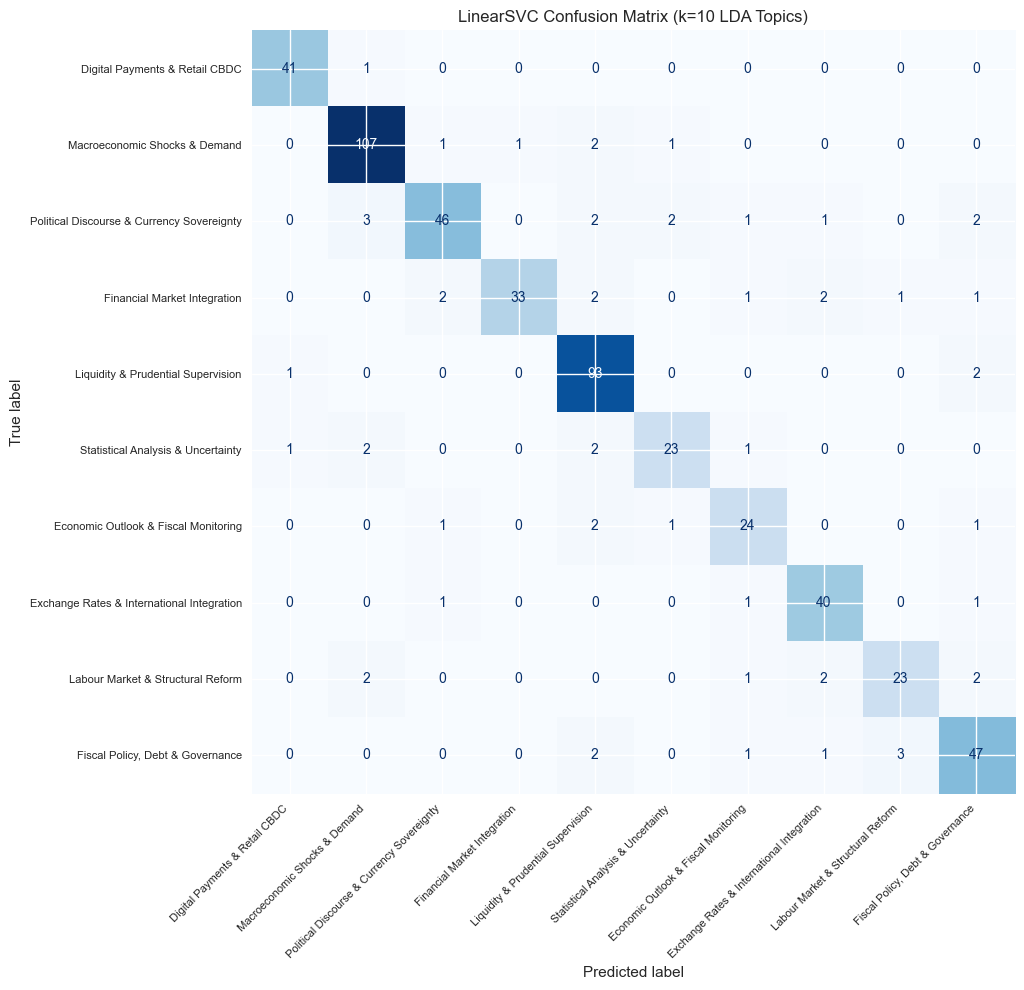

In [ ]:
# LinearSVC with GridSearchCV 
svc_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=15000, sublinear_tf=True, ngram_range=(1, 2))),
    ("svc", LinearSVC(max_iter=5000, random_state=42))
])

svc_params = {
    "svc__C": [0.1, 1.0, 10.0],
    "tfidf__max_features": [10000, 15000],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svc_grid = GridSearchCV(svc_pipe, svc_params, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
svc_grid.fit(X_train, y_train)

print(f"\nBest SVC params: {svc_grid.best_params_}")
print(f"Best CV F1 (macro): {svc_grid.best_score_:.4f}")

y_pred_svc = svc_grid.predict(X_test)
print("\nLinearSVC — Test Set")
print(classification_report(y_test, y_pred_svc, zero_division=0))

fig, ax = plt.subplots(figsize=(14, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svc, ax=ax, cmap="Blues", colorbar=False,
    display_labels=[TOPIC_LABELS[i] for i in range(chosen_k)]
)
ax.set_title("LinearSVC Confusion Matrix (k=10 LDA Topics)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 1 candidates, totalling 5 fits


python(54813) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54814) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54815) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54817) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54818) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54819) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54820) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54821) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Best XGBoost params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 4, 'xgb__n_estimators': 100}
Best CV F1 (macro): 0.7946

=== XGBoost — Test Set ===
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        42
           1       0.85      0.88      0.87       112
           2       0.82      0.72      0.77        57
           3       0.89      0.74      0.81        42
           4       0.79      0.91      0.84        96
           5       0.79      0.76      0.77        29
           6       0.84      0.72      0.78        29
           7       0.81      0.88      0.84        43
           8       0.81      0.70      0.75        30
           9       0.77      0.81      0.79        54

    accuracy                           0.83       534
   macro avg       0.83      0.80      0.81       534
weighted avg       0.83      0.83      0.82       534



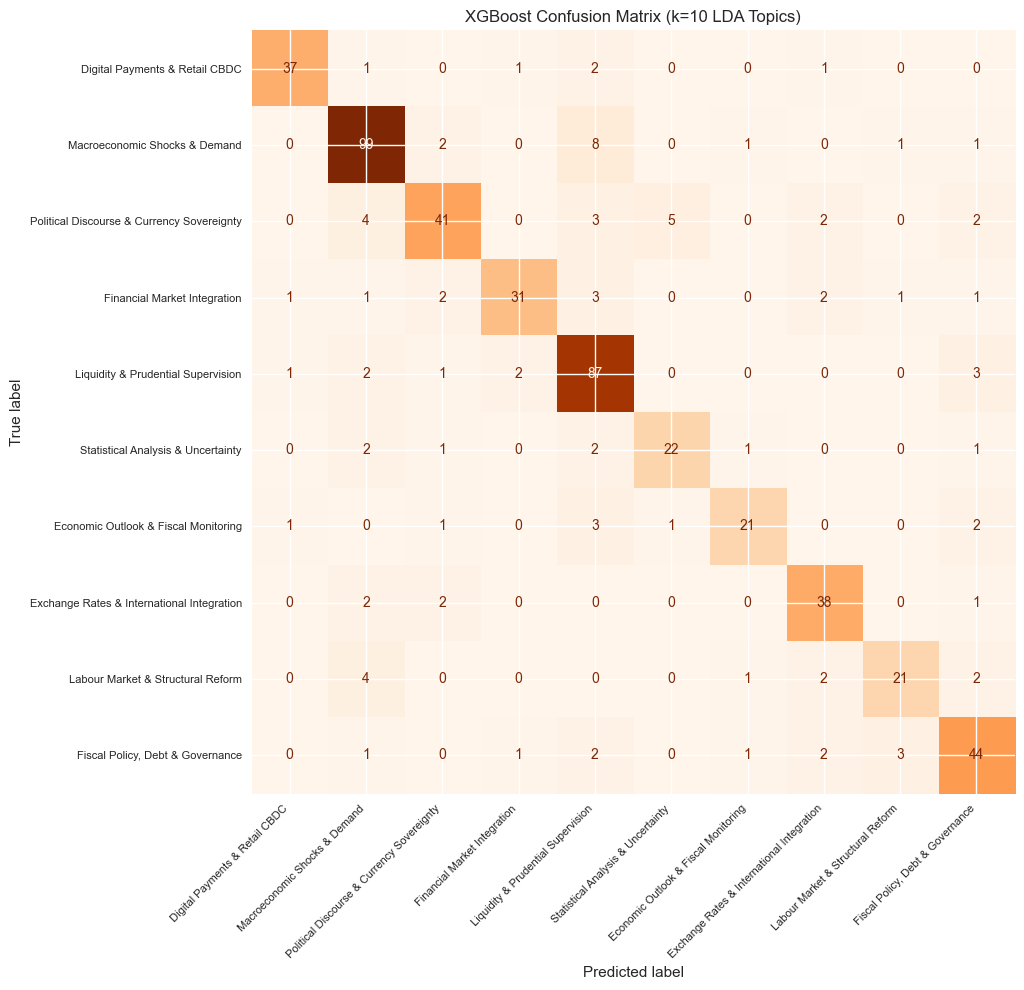

,Accuracy,F1 (macro),Best CV F1
Model,,,
LinearSVC,0.893258,0.874851,0.872145
XGBoost,0.825843,0.812402,0.794647



Step 4a (Classical Classification) complete


In [ ]:
# XGBoost with GridSearchCV 
xgb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=15000, sublinear_tf=True, ngram_range=(1, 1))), #changed this to unigram only
    ("xgb", xgb.XGBClassifier(
        objective="multi:softmax",
        eval_metric="mlogloss",
        #use_label_encoder=False,
        tree_method="hist", # for faster training
        random_state=42,
        n_jobs=-1
    ))
])

# changing these bc it took more than an hour an a half and still didnt finish running
xgb_params = {
    "xgb__n_estimators": [100],
    "xgb__max_depth": [4],
    "xgb__learning_rate": [0.1],
}

xgb_grid = GridSearchCV(xgb_pipe, xgb_params, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

print(f"\nBest XGBoost params: {xgb_grid.best_params_}")
print(f"Best CV F1 (macro): {xgb_grid.best_score_:.4f}")

y_pred_xgb = xgb_grid.predict(X_test)
print("\n=== XGBoost — Test Set ===")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

fig, ax = plt.subplots(figsize=(14, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, ax=ax, cmap="Oranges", colorbar=False,
    display_labels=[TOPIC_LABELS[i] for i in range(chosen_k)]
)
ax.set_title("XGBoost Confusion Matrix (k=10 LDA Topics)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Model comparison 
from sklearn.metrics import accuracy_score, f1_score
comparison = pd.DataFrame({
    "Model": ["LinearSVC", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_svc), accuracy_score(y_test, y_pred_xgb)],
    "F1 (macro)": [f1_score(y_test, y_pred_svc, average="macro", zero_division=0),
                   f1_score(y_test, y_pred_xgb, average="macro", zero_division=0)],
    "Best CV F1": [svc_grid.best_score_, xgb_grid.best_score_],
})
display(comparison.set_index("Model"))
print("\nStep 4a (Classical Classification) complete")

# V. Sentiment Analysis - Lexicon Based Approach


In [62]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import nltk
nltk.download("opinion_lexicon", quiet=True)
nltk.download("vader_lexicon",   quiet=True)

# pip install textblob afinn pysentiment2 nltk vaderSentiment

from nltk.corpus              import opinion_lexicon
from nltk.tokenize            import word_tokenize
from nltk.sentiment.vader     import SentimentIntensityAnalyzer
from textblob                 import TextBlob
from afinn                    import Afinn
import pysentiment2 as ps

In [63]:
# For visuals
ROLE_PALETTE = {
    "President":              "#2196F3",
    "Executive Board Member": "#FF9800",
    "Other ECB Official":     "#9E9E9E",
}
SENT_COLORS = {
    "vader":    "#7B1FA2",
    "bing_liu": "#1976D2",
    "textblob": "#388E3C",
    "afinn":    "#F57C00",
    "lm":       "#C62828",
}

### VADER

In [64]:
# VADER
# VADER (Valence Aware Dictionary and sentiment Reasoner) is rule-based and
# handles capitalisation, punctuation intensifiers, and negation without any
# preprocessing.  We apply it to the raw cleaned text (text_clean) rather than
# to tokens.
# The compound score is a normalised weighted composite in [−1, +1].

print("=" * 60)
print("15.1  VADER")
print("=" * 60)

vader = SentimentIntensityAnalyzer()

df_exp["vader_score"] = df_exp["text_clean"].apply(
    lambda text: vader.polarity_scores(text)["compound"]
)

print(df_exp.groupby("speaker_role")["vader_score"].mean().round(4))

15.1  VADER
speaker_role
Executive Board Member    0.8528
Other ECB Official        0.9996
President                 0.9380
Name: vader_score, dtype: float64


### Bing-Liu lexicon

In [65]:
# Bing-Liu lexicon

# The Bing-Liu opinion lexicon (Hu & Liu 2004) labels ~6 800 words as positive
# (+1) or negative (−1).  Score = sum of matched scores / total token count.
# We use tokens_sent (negations and pronouns preserved) for the matching,
# so "not good" contributes a negative point on "good" without an offset (the
# limitation of a bag-of-words approach).

print("\n" + "=" * 60)
print("15.2  Bing-Liu")
print("=" * 60)

# Building the lookup dictionary 
_bl_dict: dict[str, int] = {}
for w in opinion_lexicon.positive():
    _bl_dict[w] = 1
for w in opinion_lexicon.negative():
    _bl_dict[w] = -1

def bing_liu_score(token_list: list[str]) -> float:
    """
    Computing a normalised Bing-Liu sentiment score from a pre-tokenised list.
    Returning the mean sentiment across all tokens (0 if the list is empty).
    """
    if not token_list:
        return 0.0
    score = sum(_bl_dict.get(tok, 0) for tok in token_list)
    return score / len(token_list)

# tokens_sent already lower-cased and negation-preserving (built before)
df_exp["bing_liu_score"] = df_exp["tokens_sent"].apply(bing_liu_score)

print(df_exp.groupby("speaker_role")["bing_liu_score"].mean().round(6))



15.2  Bing-Liu
speaker_role
Executive Board Member    0.026030
Other ECB Official        0.032909
President                 0.044037
Name: bing_liu_score, dtype: float64


### TextBlob

In [66]:
# TextBlob
# TextBlob uses a pattern-based sentiment tagger trained on movie reviews.
# Returning:
#   • polarity    in [−1, +1]  — negative ↔ positive
#   • subjectivity in [0, 1]   — objective ↔ subjective
# Applied to text_clean so the tagger can use POS context.

print("\n" + "=" * 60)
print("15.3  TextBlob")
print("=" * 60)

def textblob_scores(text: str) -> tuple[float, float]:
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

_tb = df_exp["text_clean"].apply(textblob_scores)
df_exp["textblob_polarity"]     = _tb.apply(lambda x: x[0])
df_exp["textblob_subjectivity"] = _tb.apply(lambda x: x[1])

print(df_exp.groupby("speaker_role")[["textblob_polarity", "textblob_subjectivity"]].mean().round(4))


15.3  TextBlob
                        textblob_polarity  textblob_subjectivity
speaker_role                                                    
Executive Board Member             0.0990                 0.3811
Other ECB Official                 0.0898                 0.3871
President                          0.1112                 0.3855


### AFINN

In [67]:
# AFINN
# AFINN (Nielsen 2011) assigns integer scores from −5 (very negative) to +5
# (very positive) to ~3 300 words, including slang and emoticons.  The raw
# score is the sum of matched word values; we divide by token count to
# normalise for speech length.

print("\n" + "=" * 60)
print("15.4  AFINN")
print("=" * 60)

_afinn = Afinn(emoticons=True)

def afinn_score(text: str) -> float:
    """Raw AFINN sum divided by approximate token count for length normalisation."""
    tokens = text.split()
    if not tokens:
        return 0.0
    return _afinn.score(text) / len(tokens)

df_exp["afinn_score"] = df_exp["text_clean"].apply(afinn_score)

print(df_exp.groupby("speaker_role")["afinn_score"].mean().round(6))


15.4  AFINN
speaker_role
Executive Board Member    0.028517
Other ECB Official        0.039345
President                 0.041907
Name: afinn_score, dtype: float64


### Loughran-McDonald (LM) — Finance-Specific Lexicon

In [70]:
# Loughran-McDonald (LM) — Finance-Specific Lexicon
# Loughran & McDonald (2011) built this dictionary for SEC filings and financial
# text.  It goes beyond positive/negative to include Uncertainty, Litigious,
# Constraining, and Superfluous word lists.

# Note: pysentiment2's LM.get_score() only returns Positive, Negative, Polarity,
# and Subjectivity. We load the uncertainty word list manually from the same LM.csv 
# the library uses, and compute the density ourselves.  
# lm_polarity uses the library's built-in (pos−neg)/(pos+neg) formula.

import importlib


print("\n" + "=" * 60)
print("Loughran-McDonald")
print("=" * 60)

_lm = ps.LM()

_pysentiment2_path = importlib.resources.files("pysentiment2") / "static" / "LM.csv"
_lm_csv = pd.read_csv(_pysentiment2_path)
_lm_uncertainty_words = set(_lm_csv.query("Uncertainty > 0")["Word"].str.upper())

def lm_scores(token_list: list[str]) -> dict[str, float]:
    """ Applying Loughran-McDonald to a pre-tokenised list.
    Returning net sentiment, polarity, positive/negative density,
    and uncertainty density (all normalised by token count). """
    n = len(token_list)
    if n == 0:
        return {"lm_net": 0.0, "lm_polarity": 0.0,
                "lm_positive": 0.0, "lm_negative": 0.0, "lm_uncertainty": 0.0}
    sc = _lm.get_score(token_list)
    n_unc = sum(1 for t in token_list if t.upper() in _lm_uncertainty_words)
    return {
        "lm_net":         (sc.get("Positive", 0) - sc.get("Negative", 0)) / n,
        "lm_polarity":    sc.get("Polarity",  0),          # built-in (pos-neg)/(pos+neg)
        "lm_positive":    sc.get("Positive",  0) / n,
        "lm_negative":    sc.get("Negative",  0) / n,
        "lm_uncertainty": n_unc / n,                       # manually computed from LM.csv
    }


_lm_results = df_exp["tokens_sent"].apply(lm_scores)
df_exp["lm_net"]         = _lm_results.apply(lambda d: d["lm_net"])
df_exp["lm_polarity"]    = _lm_results.apply(lambda d: d["lm_polarity"])
df_exp["lm_positive"]    = _lm_results.apply(lambda d: d["lm_positive"])
df_exp["lm_negative"]    = _lm_results.apply(lambda d: d["lm_negative"])
df_exp["lm_uncertainty"] = _lm_results.apply(lambda d: d["lm_uncertainty"])

print(df_exp.groupby("speaker_role")[["lm_net", "lm_polarity", "lm_uncertainty"]].mean().round(6))


Loughran-McDonald
                          lm_net  lm_polarity  lm_uncertainty
speaker_role                                                 
Executive Board Member -0.004485    -0.184476        0.017889
Other ECB Official     -0.001830     0.000349        0.014262
President              -0.001300    -0.053078        0.014826


In [71]:
# Score normalisation
# Different lexicons produce scores on different scales.  We standardize each
# to zero mean and unit variance (z-score) so that cross-lexicon comparisons
# and the correlation matrix are not driven by scale differences.

SCORE_COLS = {
    "vader":    "vader_score",
    "bing_liu": "bing_liu_score",
    "textblob": "textblob_polarity",
    "afinn":    "afinn_score",
    "lm":       "lm_net",
}

scaler = StandardScaler()
for label, col in SCORE_COLS.items():
    df_exp[f"{label}_z"] = scaler.fit_transform(df_exp[[col]])

Z_COLS = [f"{k}_z" for k in SCORE_COLS]  # shorthand list used in plots below


Temporal trend


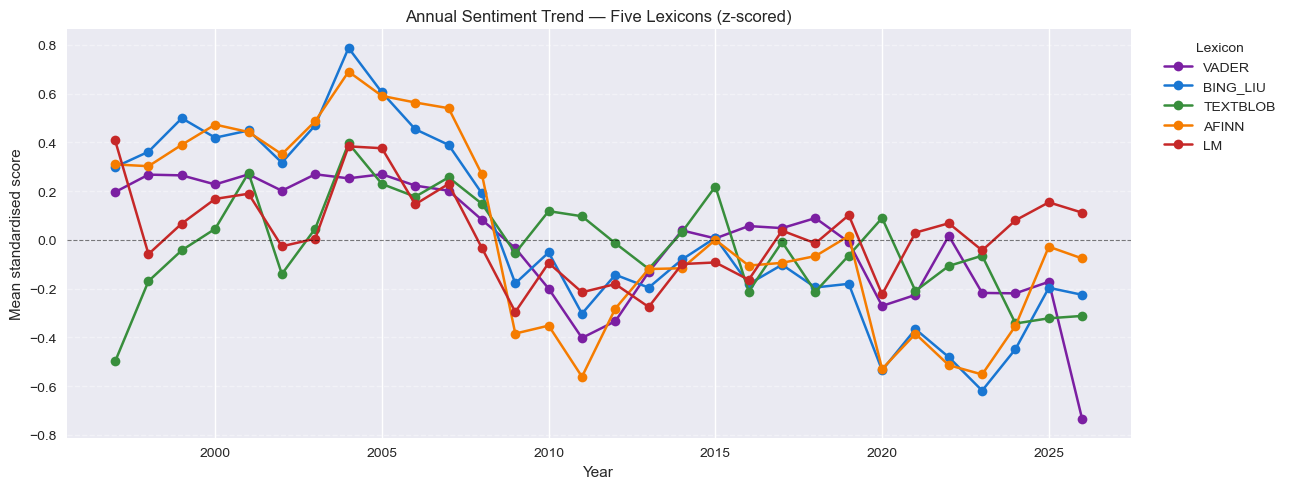

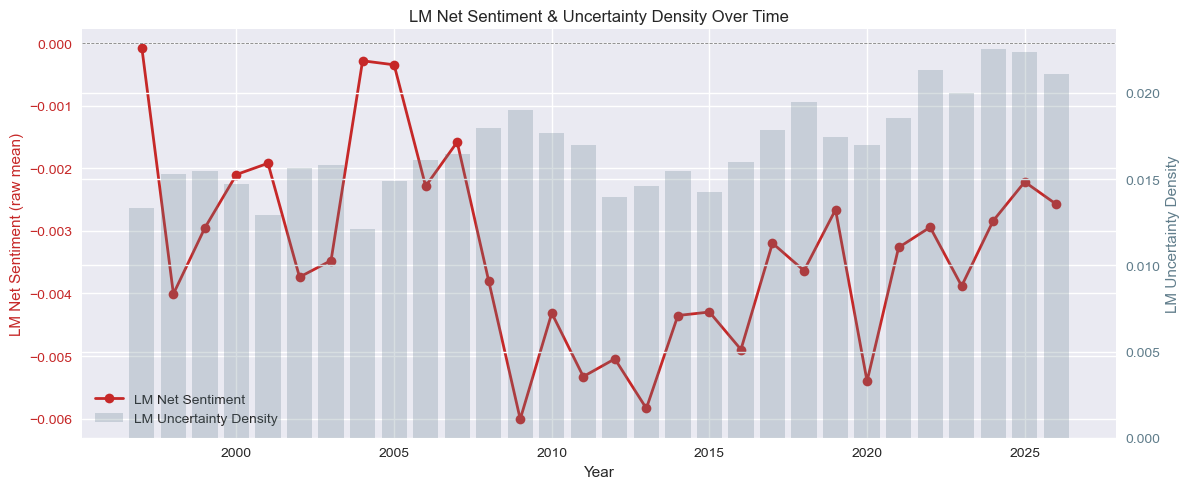

In [72]:
# Temporal trend — annual mean sentiment per lexicon
# Annual averages reveal how ECB communication tone evolved across monetary
# policy phases (dot-com bust, GFC, sovereign debt crisis, COVID, hiking cycle).

print("\n" + "=" * 60)
print("Temporal trend")
print("=" * 60)

df_exp["year"] = df_exp["date"].dt.year
annual = df_exp.groupby("year")[Z_COLS].mean()

fig, ax = plt.subplots(figsize=(13, 5))
for label, z_col in zip(SCORE_COLS.keys(), Z_COLS):
    ax.plot(annual.index, annual[z_col],
            marker="o", linewidth=1.8,
            color=SENT_COLORS[label], label=label.upper())

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Mean standardised score")
ax.set_title("Annual Sentiment Trend — Five Lexicons (z-scored)")
ax.legend(title="Lexicon", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Focus plot: LM net sentiment + LM uncertainty (most informative for ECB)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

annual_lm = df_exp.groupby("year")[["lm_net", "lm_uncertainty"]].mean()

ax1.plot(annual_lm.index, annual_lm["lm_net"],
         color=SENT_COLORS["lm"], marker="o", linewidth=2, label="LM Net Sentiment")
ax1.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax1.set_ylabel("LM Net Sentiment (raw mean)", color=SENT_COLORS["lm"])
ax1.tick_params(axis="y", labelcolor=SENT_COLORS["lm"])

ax2.bar(annual_lm.index, annual_lm["lm_uncertainty"],
        alpha=0.25, color="#607D8B", label="LM Uncertainty Density")
ax2.set_ylabel("LM Uncertainty Density", color="#607D8B")
ax2.tick_params(axis="y", labelcolor="#607D8B")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

ax1.set_title("LM Net Sentiment & Uncertainty Density Over Time")
ax1.set_xlabel("Year")
fig.tight_layout()
plt.show()


Sentiment by speaker role
                        vader_z  bing_liu_z  textblob_z  afinn_z    lm_z
speaker_role                                                            
Executive Board Member  -0.0584     -0.1787     -0.1107  -0.1487 -0.1151
Other ECB Official       0.2693      0.0461     -0.3848   0.2459  0.1997
President                0.1317      0.4099      0.2575   0.3392  0.2626


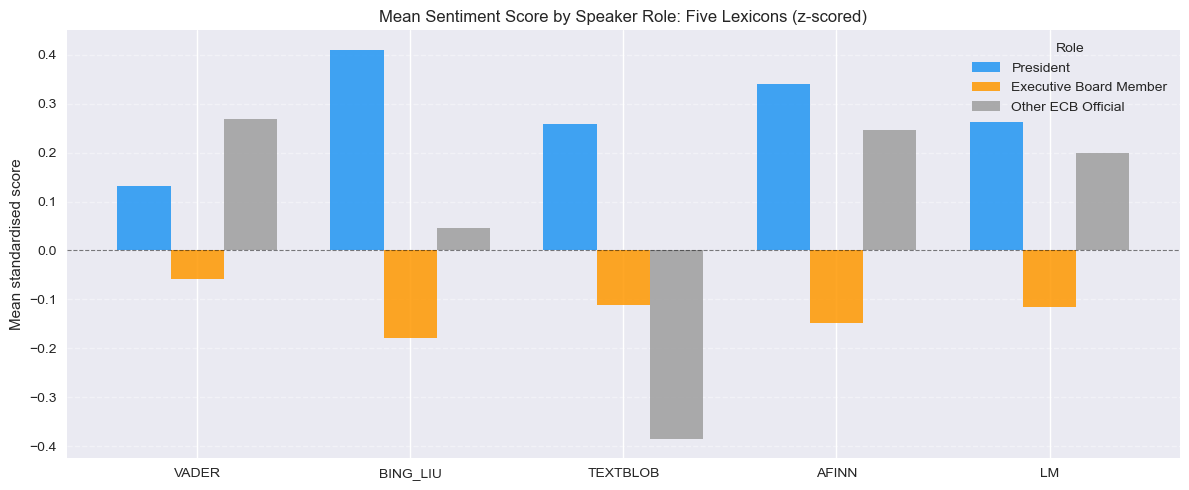

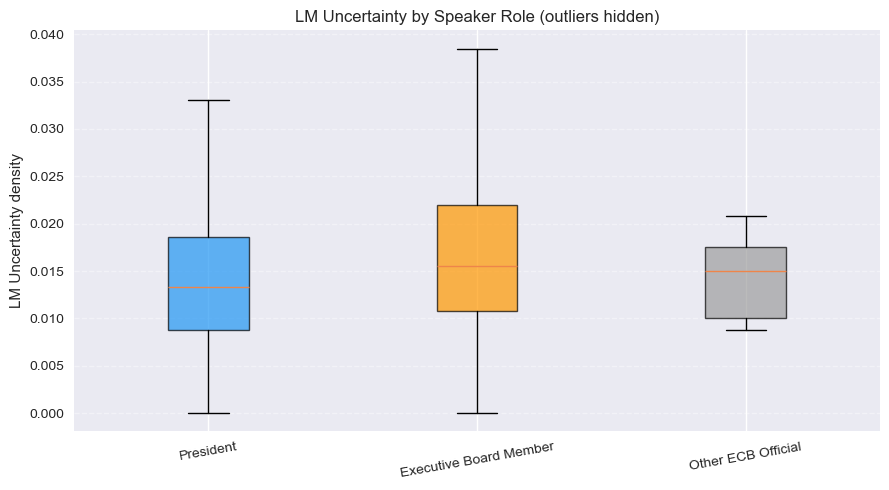

In [73]:
# Sentiment by speaker role
# Do Presidents, Executive Board Members, and Other Officials differ in tone?
# Presidents face greater public scrutiny and tend to be more deliberate; we
# might expect lower raw sentiment variance and more guarded language.

print("\n" + "=" * 60)
print("Sentiment by speaker role")
print("=" * 60)

role_means = df_exp.groupby("speaker_role")[Z_COLS].mean()
print(role_means.round(4))

roles_ordered = list(ROLE_PALETTE.keys())
x = np.arange(len(Z_COLS))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, role in enumerate(roles_ordered):
    vals = [role_means.loc[role, z] if role in role_means.index else 0 for z in Z_COLS]
    ax.bar(x + i * width, vals, width, label=role,
           color=ROLE_PALETTE[role], alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xticks(x + width)
ax.set_xticklabels([k.upper() for k in SCORE_COLS], fontsize=10)
ax.set_ylabel("Mean standardised score")
ax.set_title("Mean Sentiment Score by Speaker Role: Five Lexicons (z-scored)")
ax.legend(title="Role")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# LM uncertainty by role (box plot)
fig, ax = plt.subplots(figsize=(9, 5))
data_by_role = [df_exp.loc[df_exp["speaker_role"] == r, "lm_uncertainty"].values
                for r in roles_ordered]
bp = ax.boxplot(data_by_role, vert=True, patch_artist=True, showfliers=False)
for patch, role in zip(bp["boxes"], roles_ordered):
    patch.set_facecolor(ROLE_PALETTE[role])
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(roles_ordered) + 1))
ax.set_xticklabels(roles_ordered, rotation=10)
ax.set_ylabel("LM Uncertainty density")
ax.set_title("LM Uncertainty by Speaker Role (outliers hidden)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Sentiment by dominant LDA topic
                                             lm_net  lm_uncertainty  \
topic_label                                                           
Liquidity & Prudential Supervision         -0.00756         0.02655   
Fiscal Policy, Debt & Governance           -0.00655         0.01325   
Macroeconomic Shocks & Demand              -0.00435         0.01935   
Statistical Analysis & Uncertainty         -0.00313         0.01922   
Economic Outlook & Fiscal Monitoring       -0.00279         0.01667   
Digital Payments & Retail CBDC             -0.00220         0.01093   
Political Discourse & Currency Sovereignty -0.00196         0.01194   
Exchange Rates & International Integration -0.00023         0.01230   
Labour Market & Structural Reform          -0.00014         0.01249   
Financial Market Integration                0.00187         0.01275   

                                            vader_score  textblob_polarity  
topic_label                          

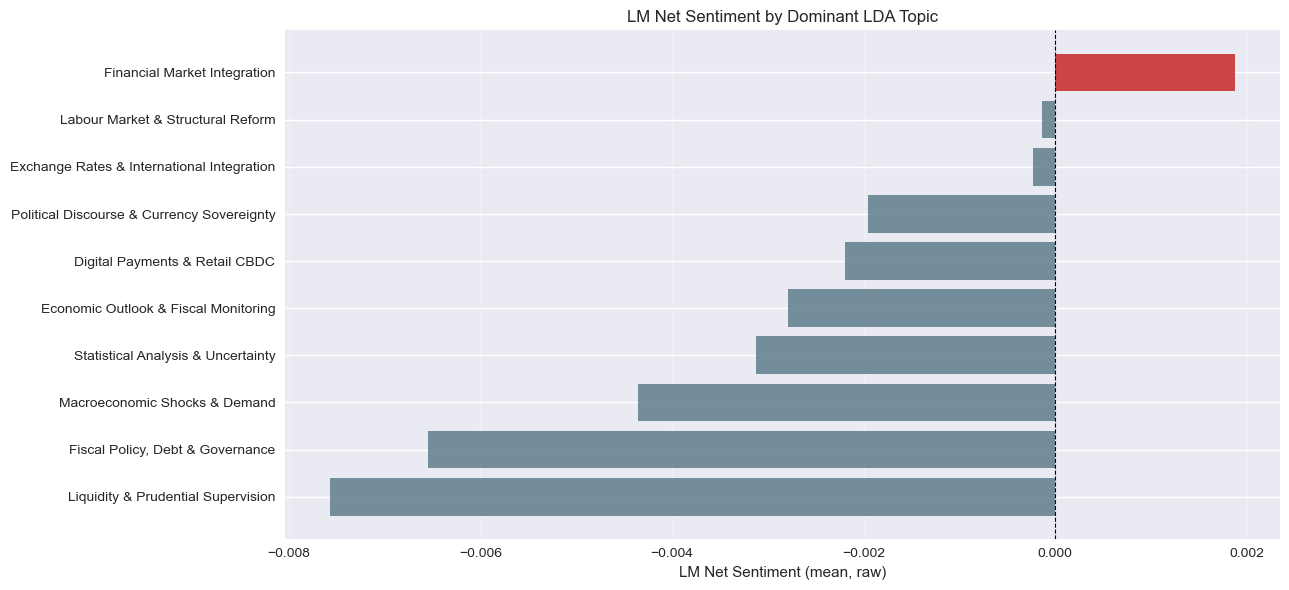

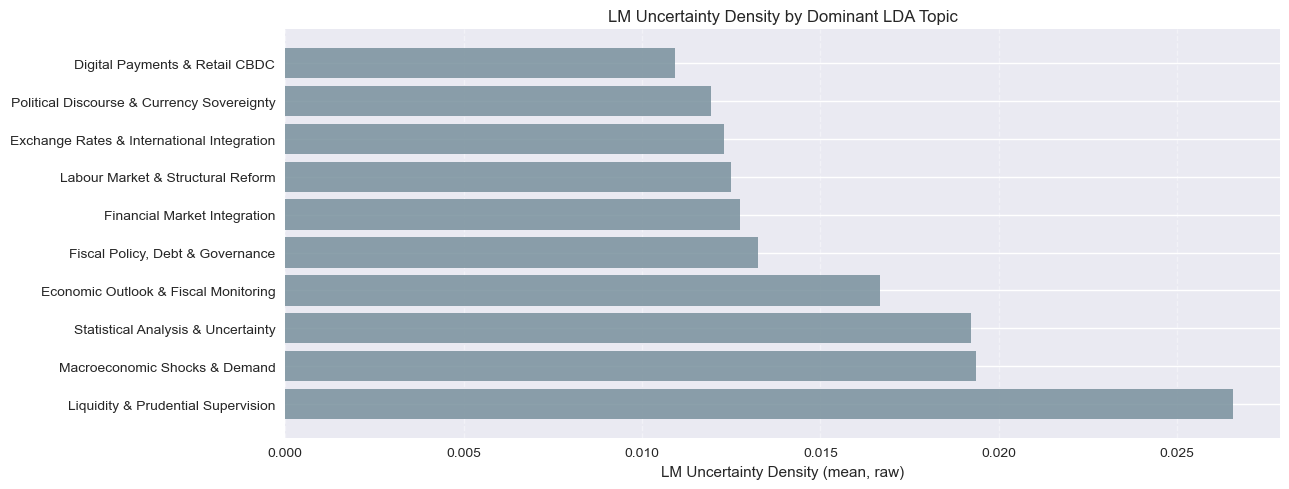

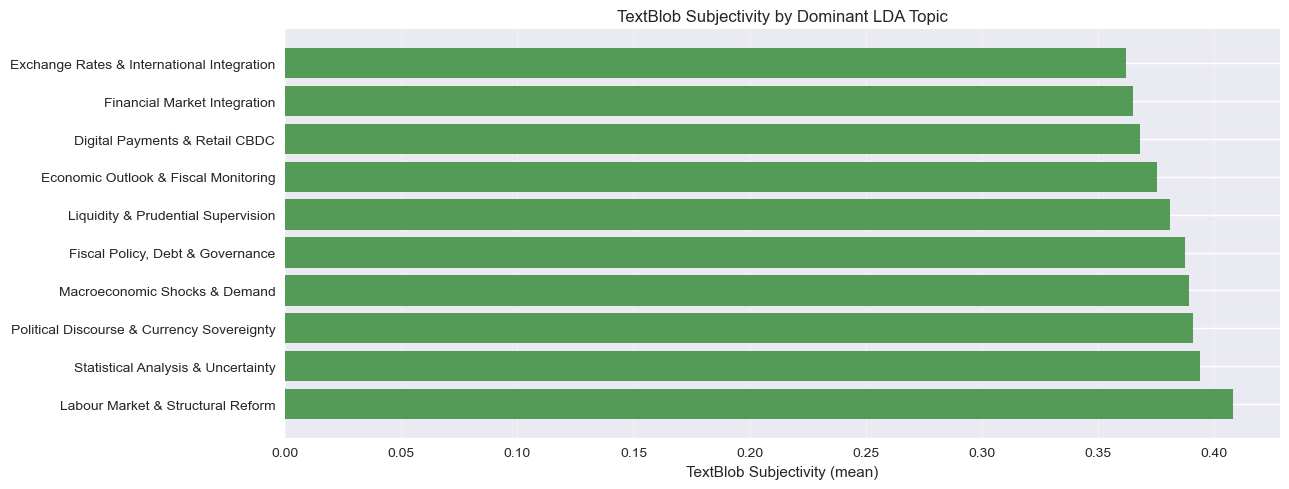

In [74]:
# Sentiment by dominant LDA topic
# Linking lexicon scores back to the ten LDA topics reveals which policy themes
# carry the most positive/negative or uncertain language.  For instance,
# "Fiscal Policy & Debt" may score more negatively than "Digital Payments &
# Retail CBDC" simply because debt-crisis discourse is inherently cautious.

print("\n" + "=" * 60)
print("Sentiment by dominant LDA topic")
print("=" * 60)

topic_means = df_exp.groupby("topic_label")[["lm_net", "lm_uncertainty",
                                              "vader_score", "textblob_polarity"]].mean()
topic_means = topic_means.sort_values("lm_net")
print(topic_means.round(5))

# LM net sentiment by topic
fig, ax = plt.subplots(figsize=(13, 6))
colors_bar = [SENT_COLORS["lm"] if v >= 0 else "#607D8B"
              for v in topic_means["lm_net"]]
ax.barh(topic_means.index, topic_means["lm_net"], color=colors_bar, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("LM Net Sentiment (mean, raw)")
ax.set_title("LM Net Sentiment by Dominant LDA Topic")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# LM uncertainty by topic 
topic_unc = df_exp.groupby("topic_label")["lm_uncertainty"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(topic_unc.index, topic_unc.values, color="#78909C", alpha=0.85)
ax.set_xlabel("LM Uncertainty Density (mean, raw)")
ax.set_title("LM Uncertainty Density by Dominant LDA Topic")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# TextBlob subjectivity by topic (complementary view) 
topic_subj = df_exp.groupby("topic_label")["textblob_subjectivity"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(topic_subj.index, topic_subj.values, color=SENT_COLORS["textblob"], alpha=0.85)
ax.set_xlabel("TextBlob Subjectivity (mean)")
ax.set_title("TextBlob Subjectivity by Dominant LDA Topic")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


LM sentiment over time by speaker role


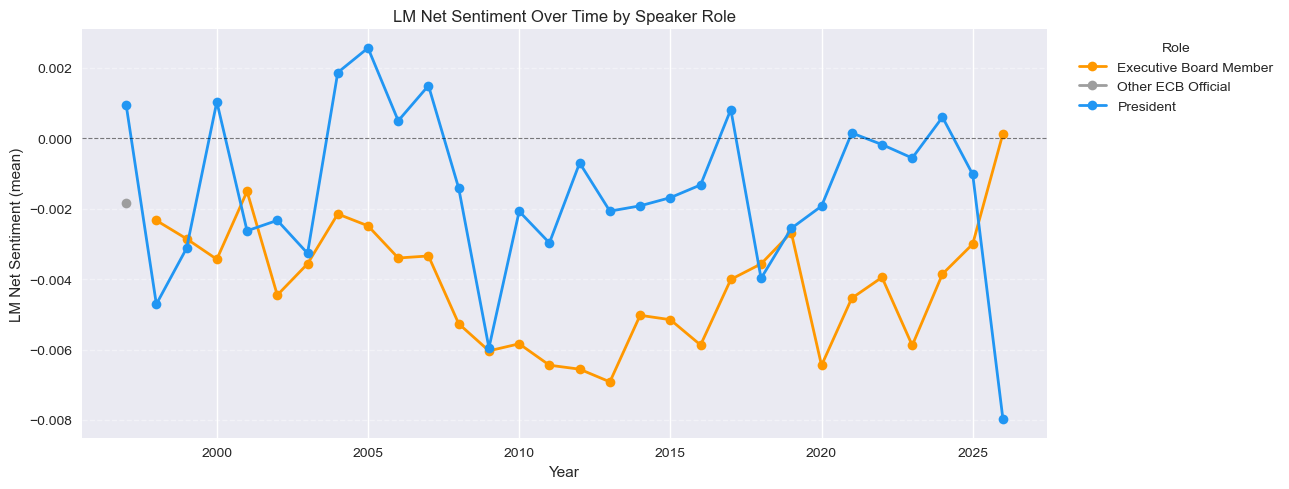

In [75]:
# LM sentiment over time, split by speaker role
# Adding role granularity to the temporal trend shows whether Presidents and
# Board Members shifted tone in unison during major macro events (e.g. GFC,
# euro-area sovereign debt crisis, COVID) or diverged.

print("\n" + "=" * 60)
print("LM sentiment over time by speaker role")
print("=" * 60)

yr_role = df_exp.groupby(["year", "speaker_role"])["lm_net"].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for role, grp in yr_role.groupby("speaker_role"):
    ax.plot(grp["year"], grp["lm_net"],
            marker="o", linewidth=2,
            color=ROLE_PALETTE.get(role, "#9E9E9E"),
            label=role)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("LM Net Sentiment (mean)")
ax.set_title("LM Net Sentiment Over Time by Speaker Role")
ax.legend(title="Role", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Cross-lexicon correlation matrix
          VADER  BING_LIU  TEXTBLOB  AFINN     LM
VADER     1.000     0.397     0.128  0.483  0.277
BING_LIU  0.397     1.000     0.434  0.834  0.478
TEXTBLOB  0.128     0.434     1.000  0.362  0.174
AFINN     0.483     0.834     0.362  1.000  0.513
LM        0.277     0.478     0.174  0.513  1.000


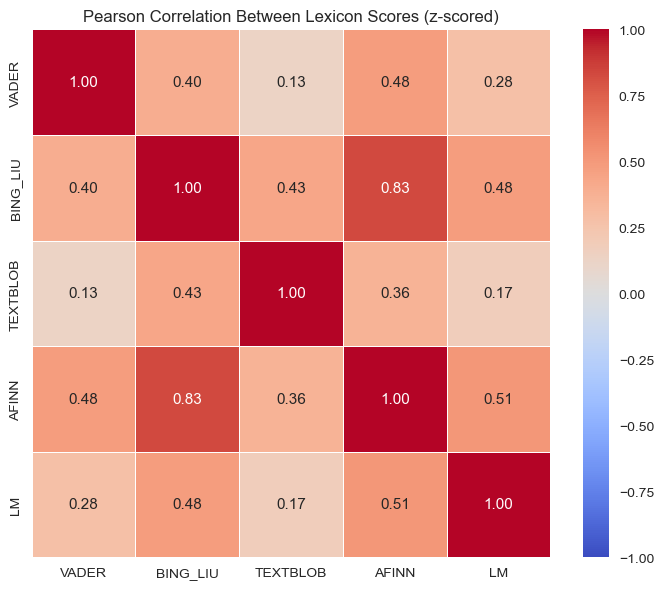

In [76]:
# Cross-lexicon correlation matrix
# If all lexicons agree, Pearson correlations between z-scores should be high.
# Low correlations (especially between general-purpose and LM scores) indicate
# that general lexicons are misfiring on financial language — exactly what
# Loughran & McDonald (2011) documented empirically.

print("\n" + "=" * 60)
print("Cross-lexicon correlation matrix")
print("=" * 60)

corr_labels = list(SCORE_COLS.keys())
corr_matrix = df_exp[[f"{k}_z" for k in corr_labels]].corr()
corr_matrix.index   = [k.upper() for k in corr_labels]
corr_matrix.columns = [k.upper() for k in corr_labels]
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 11})
ax.set_title("Pearson Correlation Between Lexicon Scores (z-scored)")
plt.tight_layout()
plt.show()

In [77]:
# Summary table
# Aggregated mean of all five scores (z-scored) alongside LM uncertainty,
# grouped by year and speaker role


print("\n" + "=" * 60)
print("15.12  Summary table — mean scores by year and role")
print("=" * 60)

summary_cols = Z_COLS + ["lm_uncertainty"]
summary_by_role = df_exp.groupby("speaker_role")[summary_cols].mean().round(4)
summary_by_role.columns = [k.upper() for k in list(SCORE_COLS.keys())] + ["LM_UNCERT"]
print("\nBy speaker role (z-scored + LM uncertainty):")
print(summary_by_role.to_string())

# Optional: save to CSV for the appendix
summary_by_role.to_csv("sentiment_summary_by_role.csv")
df_exp.groupby("year")[summary_cols].mean().round(5).to_csv("sentiment_summary_by_year.csv")
print("\nSaved: sentiment_summary_by_role.csv, sentiment_summary_by_year.csv")


15.12  Summary table — mean scores by year and role

By speaker role (z-scored + LM uncertainty):
                         VADER  BING_LIU  TEXTBLOB   AFINN      LM  LM_UNCERT
speaker_role                                                                 
Executive Board Member -0.0584   -0.1787   -0.1107 -0.1487 -0.1151     0.0179
Other ECB Official      0.2693    0.0461   -0.3848  0.2459  0.1997     0.0143
President               0.1317    0.4099    0.2575  0.3392  0.2626     0.0148

Saved: sentiment_summary_by_role.csv, sentiment_summary_by_year.csv
